# Spatial Detection — Foreign-Target Comparison (final, multi-seed)

Compares our detectors on **foreign** (out-of-scene) targets across three scenes.

**Detectors** (toggle in any cell via `active_detectors`):
`DSM` · `DSM-CFAR` · `NeighborMLP` · `NeighborMLP-CFAR` · `AMF` · `AMF-local` · `GMM-Levin`
- `DSM-CFAR` = global DSM with **local mean-reduce + local-Fisher (variance) normalization** (window `dsm_cfar_window`).
- `AMF-local` = AMF on a per-pixel window SCM, with its **own window** `amf_local_window` (independent of `k`).

*(More baselines can be added later — see the registry in `run_compare.DET_ORDER`.)*

**Scenes:** 0 (manual box 0), 2 (manual box 2), 4 (random box, seed 42).
Each scene cell runs **foreign targets only**, over **`SEEDS` = (42,43,44,45,46)**,
and aggregates to a **mean ± std** table + bar figures (AUC/pAUC, Pd@Pfa vs
Pd@train-CFAR-threshold, realized Pfa). The target class is one **absent** from
the scene (listed in the cell comment). Tune `foreign_class`, `amplitude`,
`n_budget`, `k`, `amf_local_window`, `dsm_cfar_window`, `active_detectors`, and
`SEEDS` per cell.

Each scene writes a `multiseed_<ts>/` folder with `summary_foreign.{csv,md}`,
`*_bar.{pdf,png}`, and one trained model per seed under `seeds/`. The final cell
pools all three scenes into one combined table.

In [ ]:
# ── Cell 1: Clone repo + install deps ─────────────────────────────────
import os, sys

REPO_URL      = 'https://github.com/michaelpiro/final-paper-experiment.git'
LOCAL_PROJECT = '/content/proj'
BRANCH        = 'iid-unified-experiment'

if os.path.exists(os.path.join(LOCAL_PROJECT, '.git')):
    !git -C {LOCAL_PROJECT} fetch --all -q
    !git -C {LOCAL_PROJECT} checkout {BRANCH} -q
    !git -C {LOCAL_PROJECT} pull origin {BRANCH} -q
else:
    !git clone -b {BRANCH} --depth 1 {REPO_URL} {LOCAL_PROJECT}

!pip install -q scikit-learn scipy tqdm matplotlib pyyaml pandas

for p in [LOCAL_PROJECT, os.path.join(LOCAL_PROJECT, 'experiments', 'spatial')]:
    if p not in sys.path:
        sys.path.insert(0, p)
os.chdir(LOCAL_PROJECT)
print('Ready. CWD:', os.getcwd())
!git -C {LOCAL_PROJECT} log --oneline -1

Cloning into '/content/proj'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (168/168), done.
remote: Compressing objects: 100% (146/146), done.
remote: Total 168 (delta 23), reused 115 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (168/168), 40.63 MiB | 23.32 MiB/s, done.
Resolving deltas: 100% (23/23), done.
Ready. CWD: /content/proj
c1ccf87 (grafted, HEAD -> iid-unified-experiment, origin/iid-unified-experiment) multiclass: detach Sigma in LRao (stability for MLP LRao)


In [ ]:
# ── Cell 2: GPU check ─────────────────────────────────────────────────
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'enable GPU runtime')

Device: cuda | Tesla T4


In [ ]:
# ── Cell 3: Mount Drive + COPY pavia-u.mat to local disk ──────────────
# NOTE: scipy.loadmat reading directly through the Drive FUSE mount can fail
# with "OSError: could not read bytes" on large files. We copy the .mat to
# local /content disk and read from there.
import os, shutil
RESULTS = '/content/results'
DATASET = '/content/pavia-u.mat'          # LOCAL copy (used everywhere downstream)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS = '/content/drive/MyDrive/final_paper/spatial_results'
    if not os.path.exists(DATASET):
        for src in ['/content/drive/MyDrive/final_paper/pavia-u.mat',
                    '/content/drive/MyDrive/final_paper/real_datasets/pavia-u.mat']:
            if os.path.exists(src):
                shutil.copy(src, DATASET)
                print(f'Copied dataset ({os.path.getsize(DATASET)/1e6:.1f} MB) from {src}')
                break
        else:
            print('WARNING: pavia-u.mat not found on Drive.')
    else:
        print('Local dataset already present.')
except Exception as e:
    print('Drive not mounted:', repr(e))

os.makedirs(RESULTS, exist_ok=True)
assert os.path.exists(DATASET), 'pavia-u.mat missing! Mount Drive and re-run this cell.'
print('DATASET:', DATASET)
print('RESULTS dir:', RESULTS)

Mounted at /content/drive
Copied dataset (87.1 MB) from /content/drive/MyDrive/final_paper/pavia-u.mat
DATASET: /content/pavia-u.mat
RESULTS dir: /content/drive/MyDrive/final_paper/spatial_results


In [ ]:
# ── Cell 4: Helpers (reload + run + show) ─────────────────────────────
import importlib, sys, os
import run_compare as rc
importlib.reload(rc)

# DATASET is set by Cell 3 (local copy). Fall back only if Cell 3 was skipped.
try:
    DATASET
except NameError:
    DATASET = '/content/pavia-u.mat'
MANUAL = '/content/proj/experiments/spatial/manual_boxes.json'

def _fill(ov):
    ov = dict(ov)
    ov.setdefault('dataset', DATASET)
    ov.setdefault('manual_boxes_path', MANUAL)
    ov.setdefault('results_dir', RESULTS)
    return ov

def run_and_show(ov, show=True):
    """Single-seed run of one scene; show the foreign-target results."""
    importlib.reload(rc)
    ov = _fill(ov)
    rd = rc.run_from_cfg(ov)
    if show:
        sub = 'foreign' if ov.get('run_foreign', True) else None
        rc.show_plots_from_dir(rd, sub=sub)
    return rd

def run_seeds_and_show(ov, seeds=(42, 43, 44, 45, 46), show=True):
    """Run one scene over multiple seeds, aggregate to a mean±std table,
    and show the aggregate bar figures + representative qualitative plots."""
    importlib.reload(rc)
    parent = rc.run_multiseed(_fill(ov), seeds=seeds)
    if show:
        rc.show_multiseed(parent)
    return parent

print('Helpers ready. DATASET =', DATASET, '| DET_ORDER =', rc.DET_ORDER)

Helpers ready. DATASET = /content/pavia-u.mat | DET_ORDER = ['DSM', 'DSM-CFAR', 'NeighborMLP', 'NeighborMLP-CFAR', 'AMF', 'AMF-local', 'GMM-Levin']


In [ ]:
# ── Cell 5: BASE config (edit defaults here; override per scene below) ─
SEEDS = (42, 43, 44, 45, 46)   # ← seeds for the multi-seed mean±std tables

BASE = dict(
    # ── scene / protocol ──
    norm_mode         = 'none',
    sig_dom_weight    = 0.8,
    sig_mean_weight   = 0.2,
    random_scenario_seeds = [42, 123, 456, 789],
    min_pixels        = 3000,

    # ── run only FOREIGN targets ──
    run_inpatch       = False,
    run_foreign       = True,

    # ── which detectors to run/show (omit to run all of DET_ORDER) ──
    # DSM-CFAR = global DSM + local mean-reduce + local-Fisher normalization.
    # AMF-local = AMF on a per-pixel window SCM (its own window, see below).
    active_detectors  = ['DSM', 'DSM-CFAR', 'NeighborMLP', 'NeighborMLP-CFAR',
                         'AMF', 'AMF-local', 'GMM-Levin'],

    # ── spatial window (neighborhood k for NeighborMLP & CFAR variants) ──
    k                 = 5,

    # ── AMF-local own window (independent of k) + DSM-CFAR window (adjust here) ──
    amf_local_window  = 15,      # AMF-local SCM window; None → reuse k
    dsm_cfar_window   = 11,     # DSM-CFAR local mean/Fisher window (k×k)
    dsm_cfar_guard    = 3,      # DSM-CFAR inner guard window (0 → none)

    # ── target planting ──
    amplitude         = 0.15,
    target_fraction   = 0.10,
    edge_guard        = 3,
    n_budget          = None,         # None = full train box; int = side-crop

    # ── DSM (global) ──
    dsm_hidden        = [128],
    dsm_epochs        = 1000,
    dsm_lr            = 5e-4,

    # ── NeighborMLP ──
    nmlp_d_lat        = 16,
    nmlp_K            = 7,
    nmlp_enc_hidden   = [64, 32],
    nmlp_score_hidden = [128],
    nmlp_epochs       = 1000,
    nmlp_lr           = 3e-4,
    nmlp_batch        = 512,

    # ── GMM-Levin ──
    gmm_K             = 9,
    gmm_steps         = 50,

    # ── baselines ──
    local_scm_loading = 1e-12,
    baseline_eig_floor= 1e-12,

    # ── shared ──
    activation        = 'relu',
    dsm_sigma_rho     = 0.05,
    whiten_mode       = 'zca',
    whiten_eig_floor  = 1e-5,
    batch_size        = 256,
    weight_decay      = 1e-5,
    pfa_target        = 0.05,
    seed              = 42,            # overridden per-seed inside run_multiseed
)
print('BASE config ready.  seeds =', SEEDS, ' active_detectors =', BASE['active_detectors'])
print('AMF-local window =', BASE['amf_local_window'], ' DSM-CFAR window =', BASE['dsm_cfar_window'])

BASE config ready.  seeds = (42, 43, 44, 45, 46)  active_detectors = ['DSM', 'DSM-CFAR', 'NeighborMLP', 'NeighborMLP-CFAR', 'AMF', 'AMF-local', 'GMM-Levin']
AMF-local window = 15  DSM-CFAR window = 11


In [ ]:
# ── Cell 6: Scene overview — full false-color image + GT label map ────
import numpy as np, json, matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
import matplotlib.patches as mpatches
from final_paper_experiments.data_utils import load_and_normalize
from final_paper_experiments.evaluation import generate_random_boxes

CLS_NAMES  = {0:'unlabeled',1:'asphalt',2:'meadows',3:'gravel',4:'trees',
              5:'metal_sheets',6:'bare_soil',7:'bitumen',8:'bricks',9:'shadows'}
CLS_HEX    = {0:'#000000',1:'#808080',2:'#00cc44',3:'#d2691e',4:'#006400',
              5:'#add8e6',6:'#a52a2a',7:'#9400d3',8:'#ff4500',9:'#00008b'}

data, gt = load_and_normalize(DATASET, mode='none')
H, W, D = data.shape

def false_color(d, bands=(60,30,10)):
    rgb = d[..., list(bands)].astype(np.float32)
    lo = np.percentile(rgb, 2, (0,1), keepdims=True)
    hi = np.percentile(rgb, 98, (0,1), keepdims=True)
    return np.clip((rgb-lo)/(hi-lo+1e-9), 0, 1)

def label_img(g):
    out = np.zeros((*g.shape,3), np.float32)
    for c,hx in CLS_HEX.items(): out[g==c] = to_rgb(hx)
    return out

# scenarios: 0-3 manual, 4-7 random
manual = json.load(open(MANUAL))
rnd    = generate_random_boxes(gt, n=4, min_pixels=BASE['min_pixels'],
                               seeds=tuple(BASE['random_scenario_seeds']))
SCEN   = manual + rnd

fc, lm = false_color(data), label_img(gt)
fig, ax = plt.subplots(1, 2, figsize=(13, 9))
ax[0].imshow(fc); ax[0].set_title('False color (bands 60/30/10)'); ax[0].axis('off')
ax[1].imshow(lm); ax[1].set_title('GT label map');                ax[1].axis('off')
for sidx, col in [(0,'cyan'), (2,'yellow'), (4,'magenta')]:
    for box, ls in [(SCEN[sidx]['train_box'],'--'), (SCEN[sidx]['test_box'],'-')]:
        r0,r1,c0,c1 = box
        for a in ax:
            a.add_patch(plt.Rectangle((c0,r0), c1-c0, r1-r0, fill=False,
                                      edgecolor=col, lw=1.8, ls=ls))
    r0,r1,c0,c1 = SCEN[sidx]['test_box']
    ax[0].text(c0, r0-3, f'scen {sidx}', color=col, fontsize=9, weight='bold')
ax[1].legend(handles=[mpatches.Patch(color=CLS_HEX[c], label=CLS_NAMES[c]) for c in range(10)],
             fontsize=6, loc='center left', bbox_to_anchor=(1.01,0.5))
plt.tight_layout(); plt.show()
print('solid = test box, dashed = train box.  scen0=cyan, scen2=yellow, scen4=magenta')

solid = test box, dashed = train box.  scen0=cyan, scen2=yellow, scen4=magenta


## Scenario 0 — manual box 0


########## MULTI-SEED  seeds=[42, 43, 44, 45, 46]  -> /content/drive/MyDrive/final_paper/spatial_results/multiseed_20260612_181840

===== seed 42  (1/5) =====
Device: cuda
Loading data ...
Image 610×340×103
Scenario 0: train_box=[344, 391, 105, 177]  test_box=[316, 340, 71, 141]
train=3384 px  (box [344, 391, 105, 177])
test=1680 px  (24×70)
AMF-local window=15×15 (independent of k=5)
in-patch signature: dominant=bitumen  ||s||=1.483e+04
foreign signature: class=bricks  scaled ||s||=1.415e+04
Training DSM ...


DSM:   0%|          | 0/1000 [00:00<?, ?it/s, loss=2056.2388]

    [DSM] epoch 1/1000  loss=2056.2388  best=2056.2388


DSM:  10%|▉         | 95/1000 [00:03<00:22, 40.54it/s, loss=1705.3367]

    [DSM] epoch 100/1000  loss=1705.3367  best=1705.3367


...

    [NeighborMLP] epoch 900/1000  loss=1647.4001  best=1636.3853


NeighborMLP: 100%|█████████▉| 998/1000 [00:27<00:00, 33.54it/s, loss=1640.4345]

    [NeighborMLP] epoch 1000/1000  loss=1640.4345  best=1635.6082


  NeighborMLP done (27s)  best loss=1635.6082


  saved models -> /content/drive/MyDrive/final_paper/spatial_results/multiseed_20260612_181840/seeds/compare_20260612_182406/models.pt

########## DETECTION RUN: foreign-bricks ##########
[foreign-bricks] planted 115 targets  ||s||=1.415e+04
Scoring detectors (test) ...
Scoring detectors (train, for CFAR thresholds) ...
Active detectors: ['DSM', 'DSM-CFAR', 'NeighborMLP', 'NeighborMLP-CFAR', 'AMF', 'AMF-local', 'GMM-Levin']

=== Summary [foreign-bricks] ===
| Detector | pAUC@0.05 | AUC | Pd@Pfa=0.05 | Pd_cfar | Pfa_avg | Pfa_max | Pfa[unlabeled] | Pfa[asphalt] | Pfa[trees] | Pfa[bitumen] | Pfa[shadows] |
|---|---|---|---|---|---|---|---|---|---|---|---|
| DSM | 0.108 | 0.765 | 0.183 | 0.226 | 0.061 | 0.198 | 0.083 | 0.198 | 0.000 | 0.026 | 0.000 |
| DSM-CFAR | 0.154 | 0.767 | 0.287 | 0.252 | 0.023 | 0.042 | 0.042 | 0.037 | 0.000 | 0.038 | 0.000 |
| NeighborMLP | 0.262 | 0.893 | 0.539 | 0.400 | 0.017 | 0.055 | 0.055 | 0.025 | 0.000 | 0.007 | 0.000 |
| NeighborMLP-CFAR | 0.200 | 0.858 | 

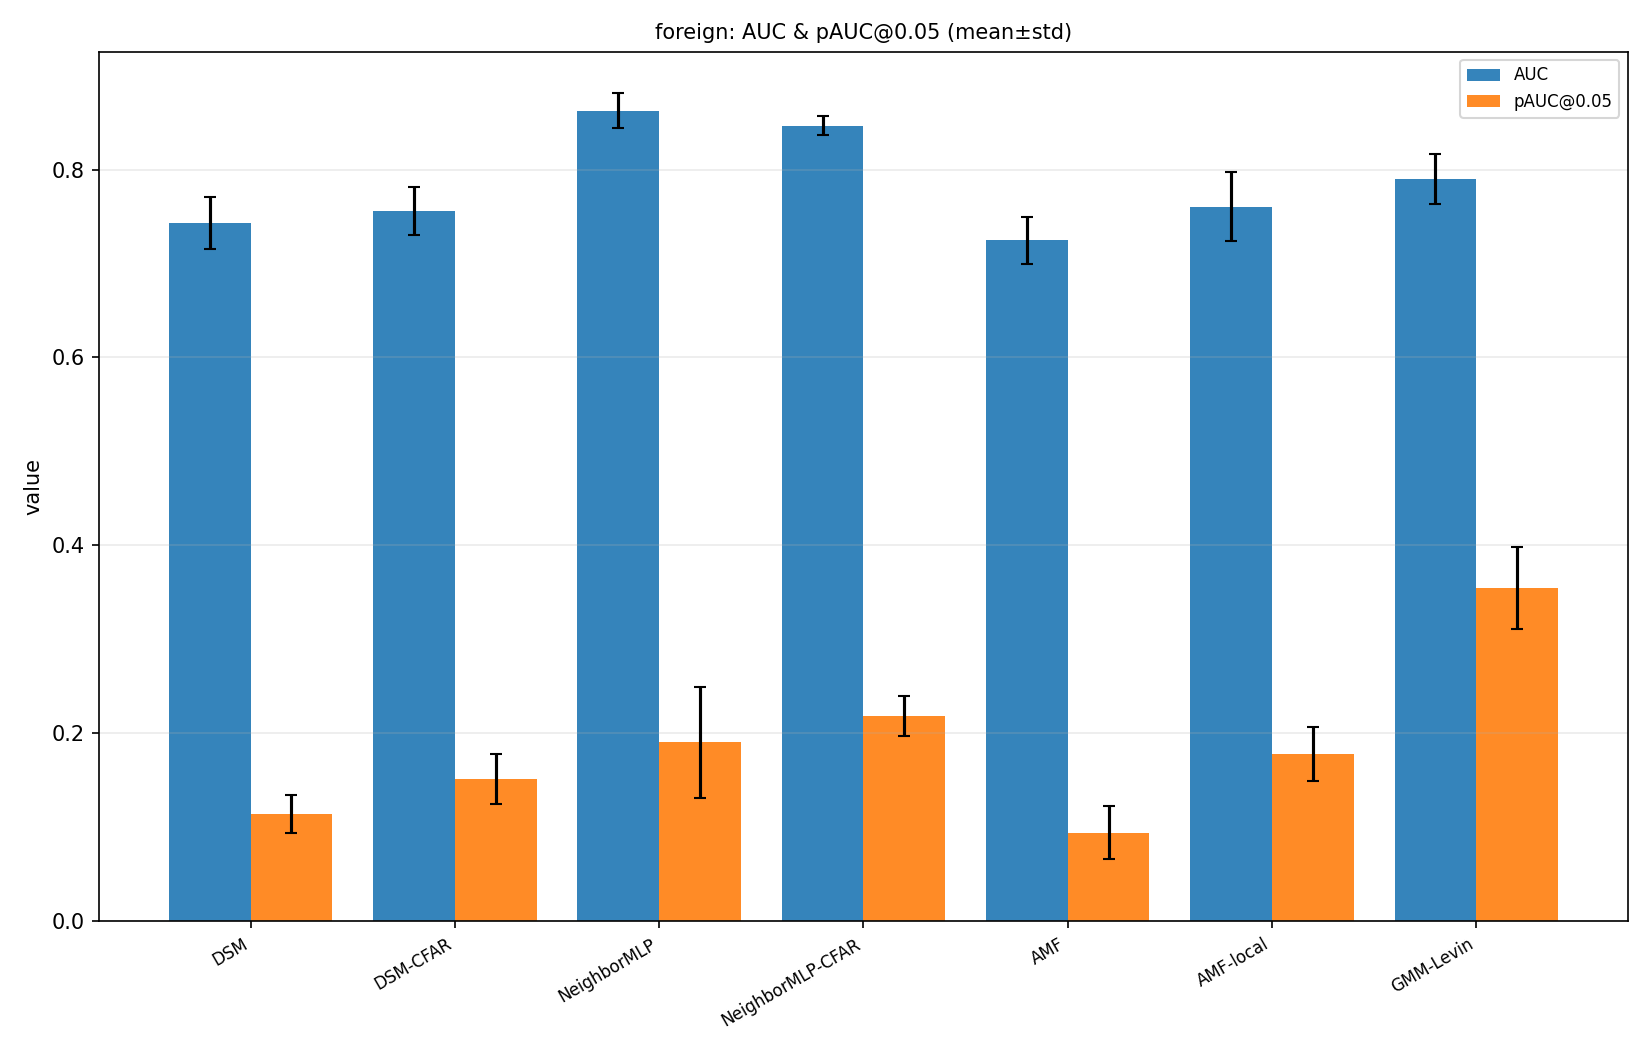

── foreign_pd_bar.png ──


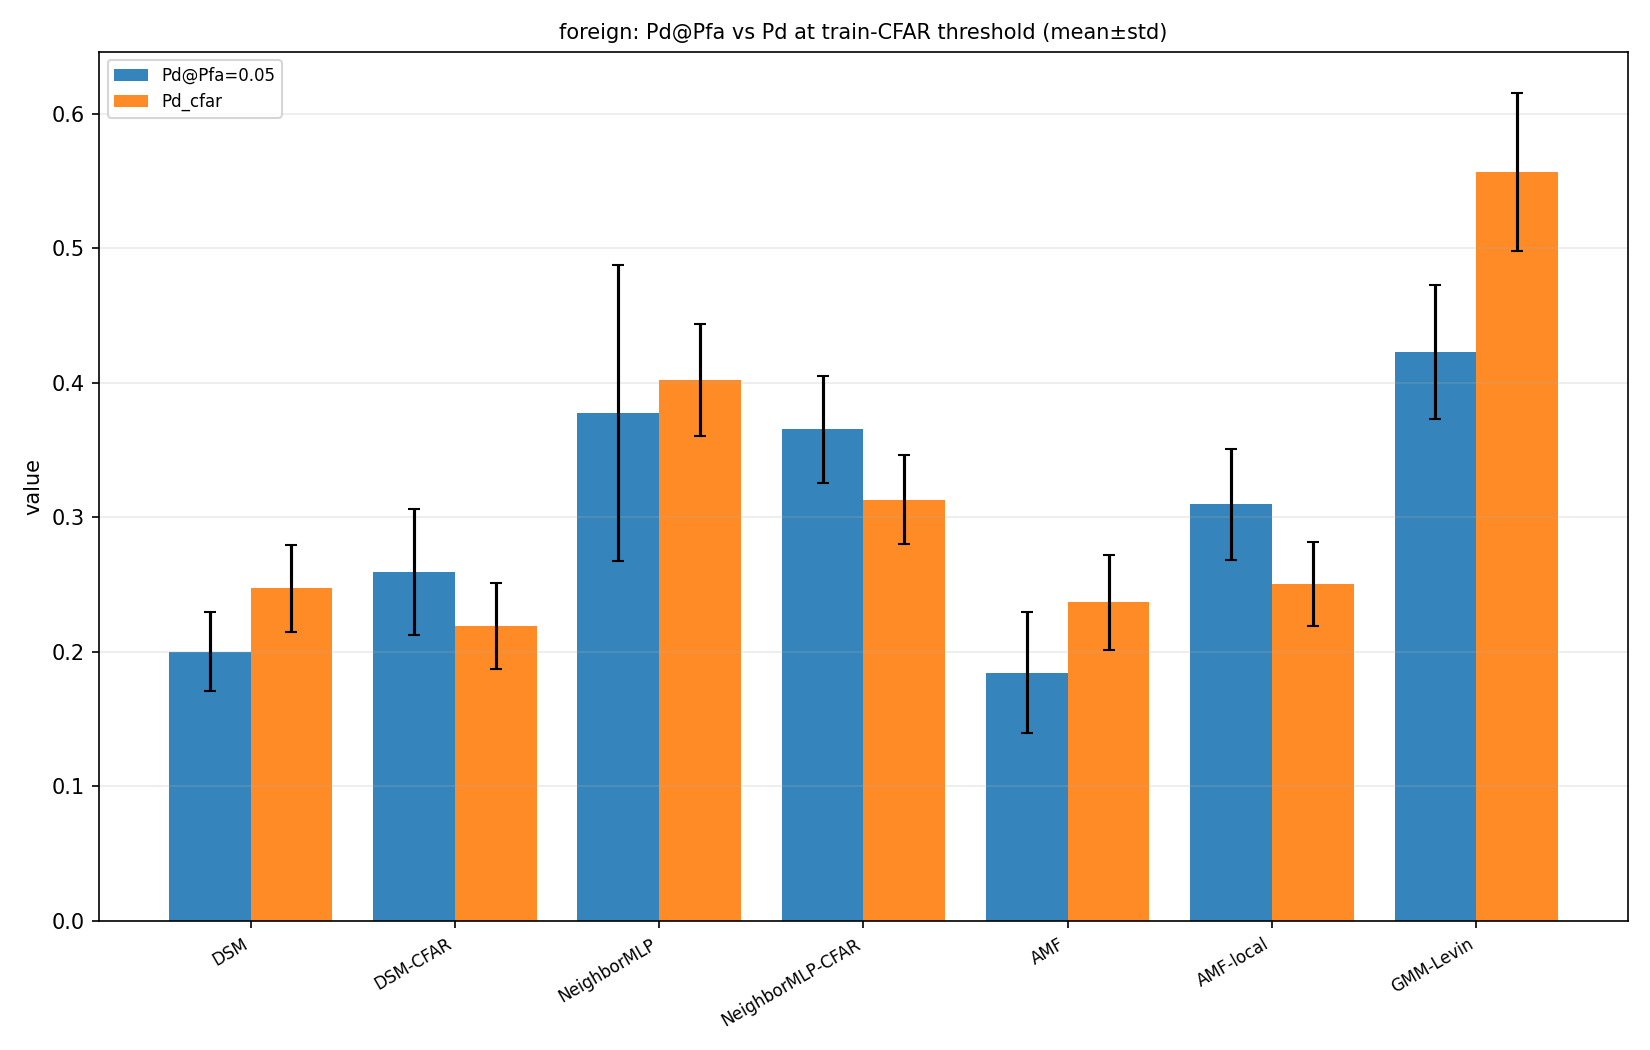

── foreign_pfa_bar.png ──


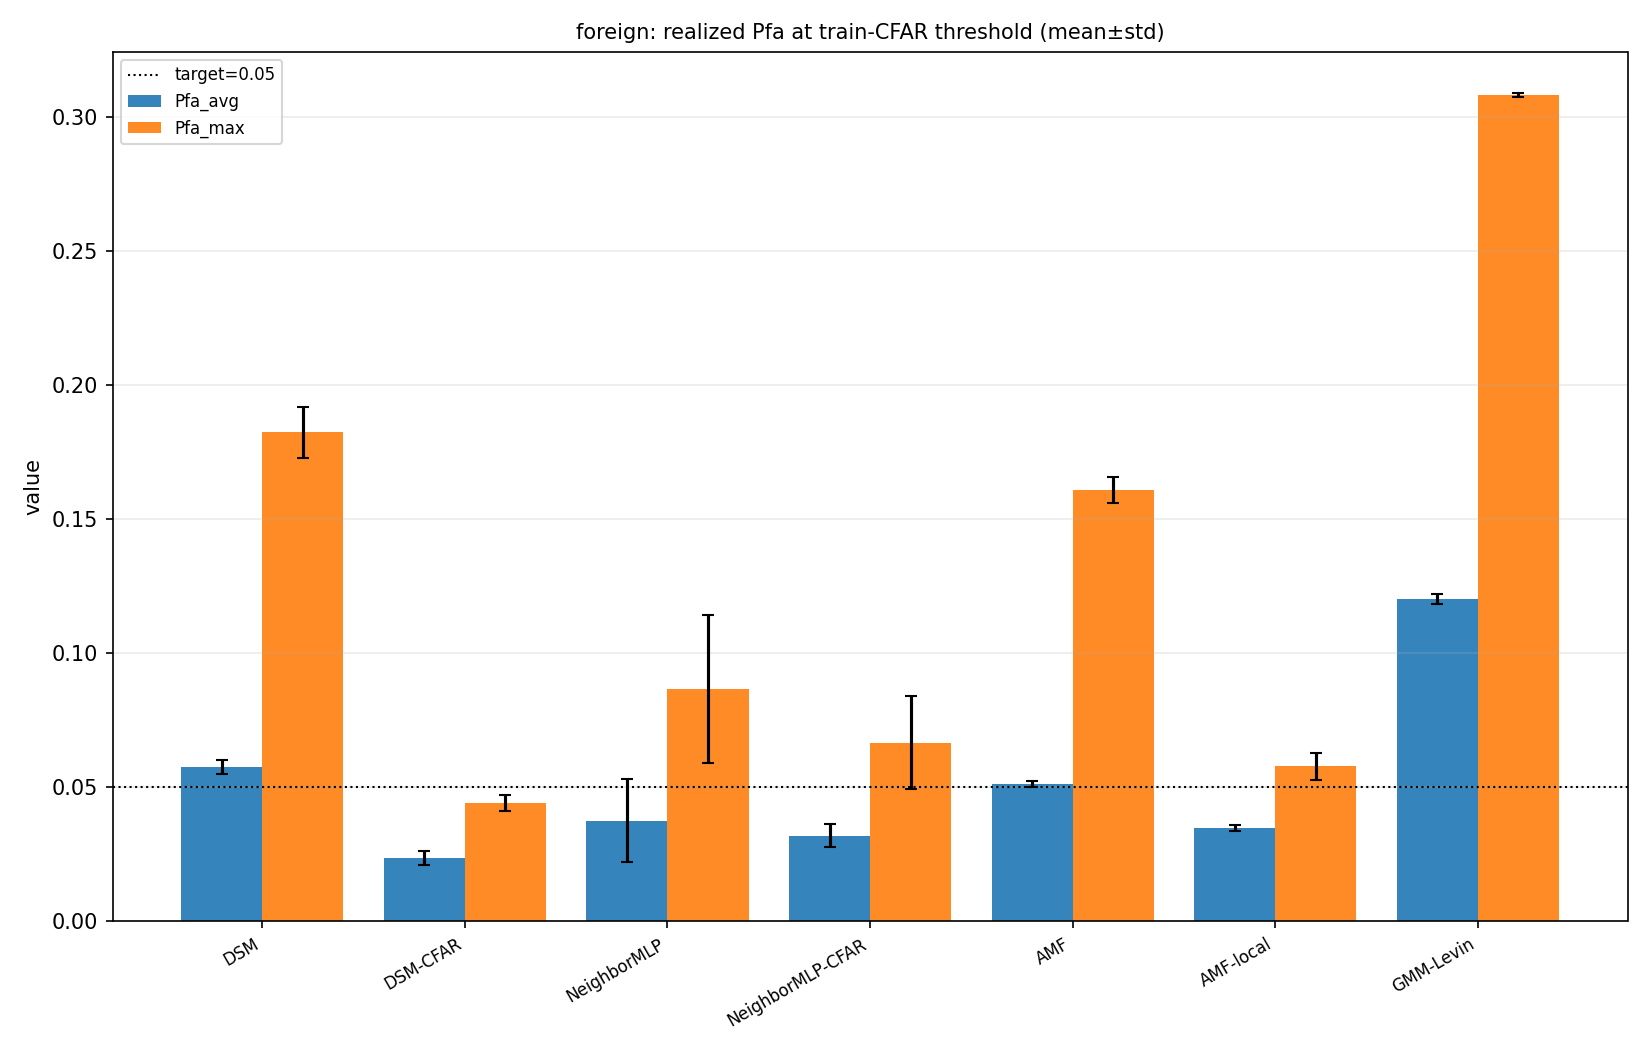


=== Representative qualitative figures (seed 42) ===
── false_color.png ──


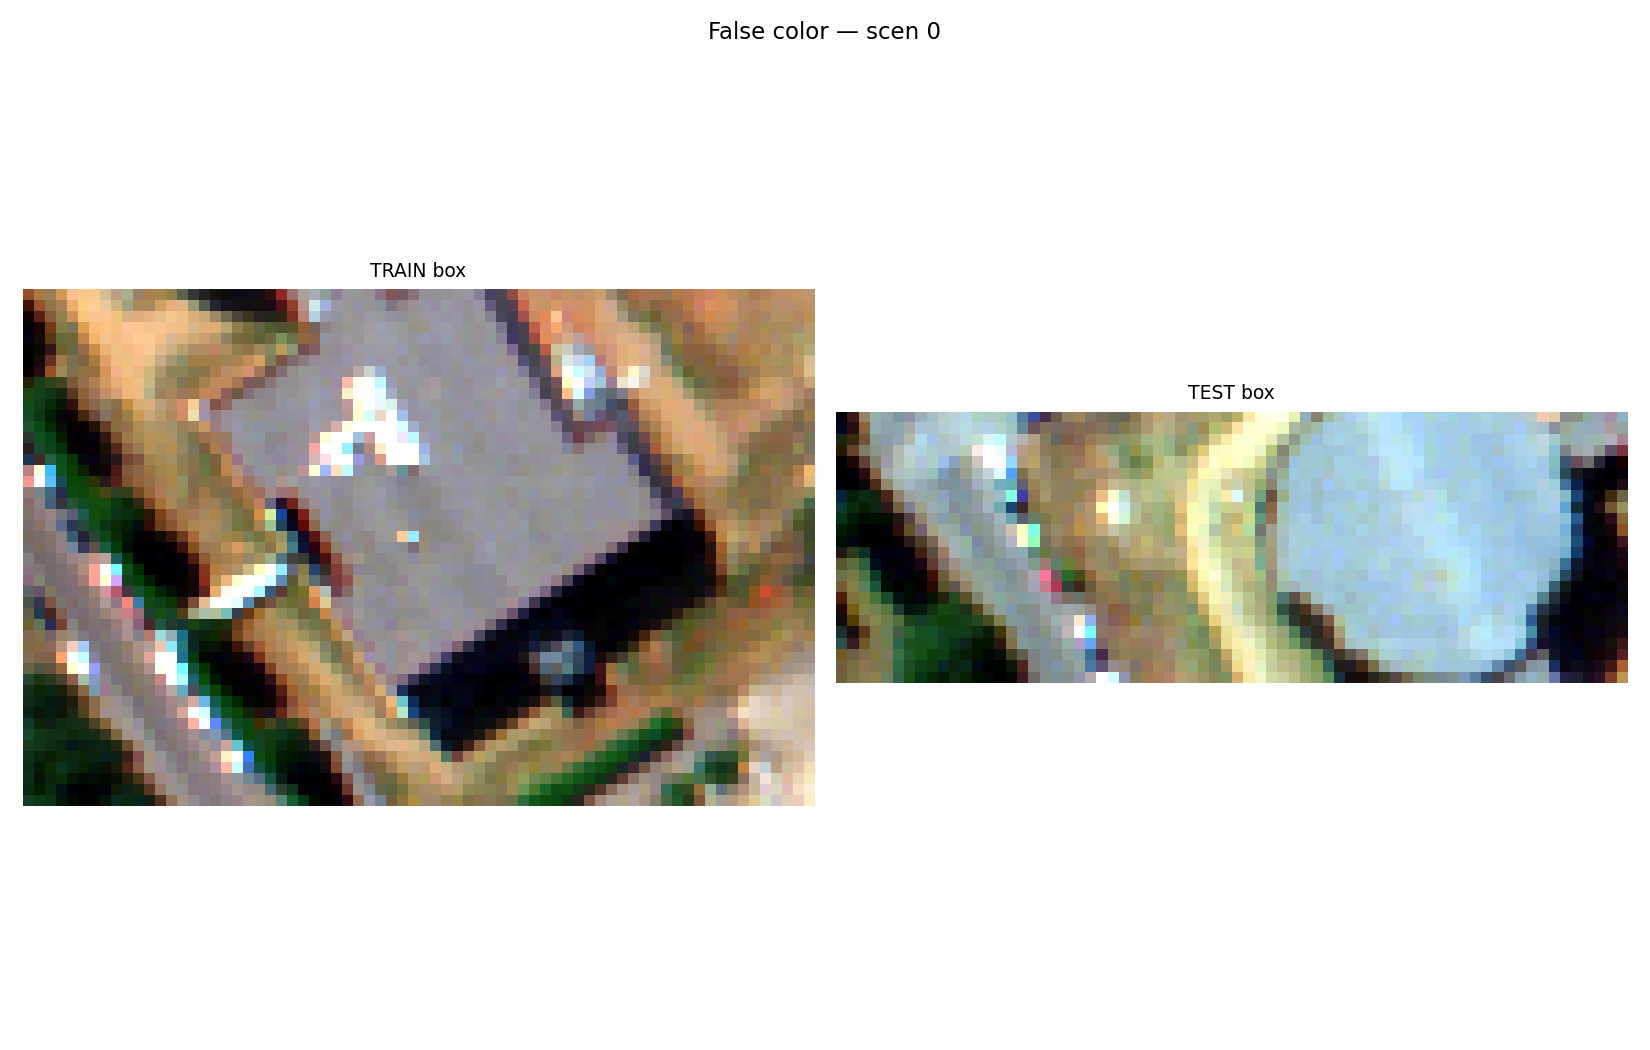

── label_map_targets.png ──


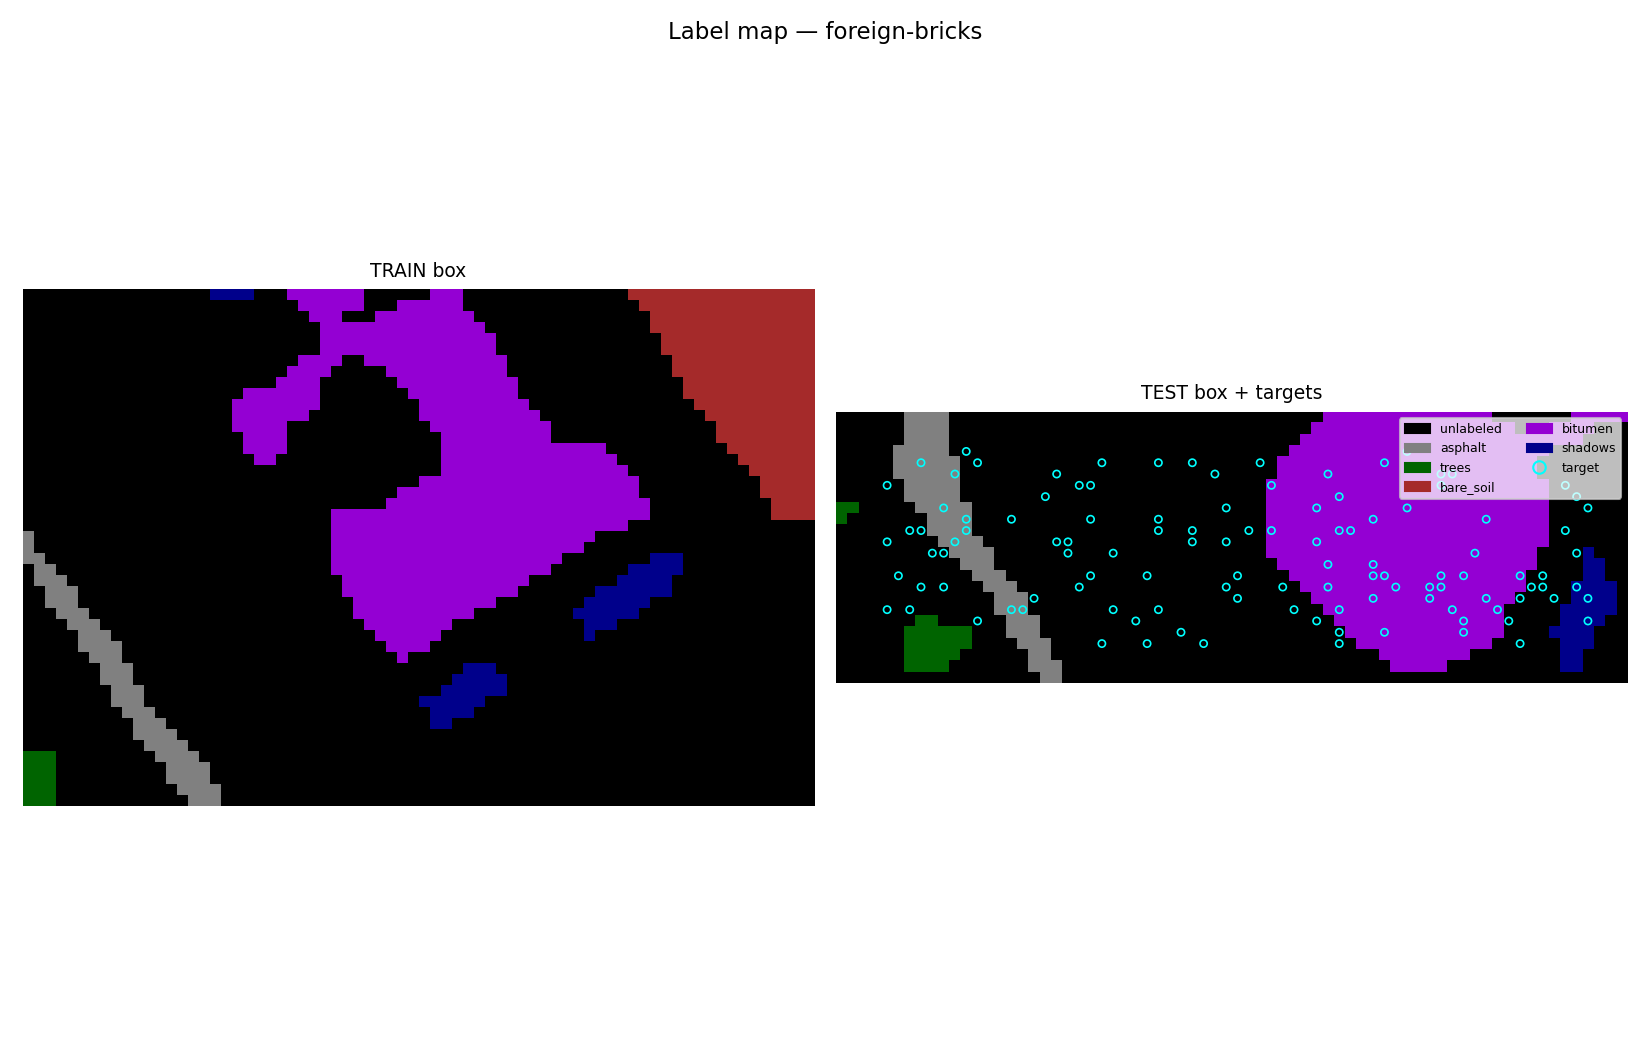

── signatures.png ──


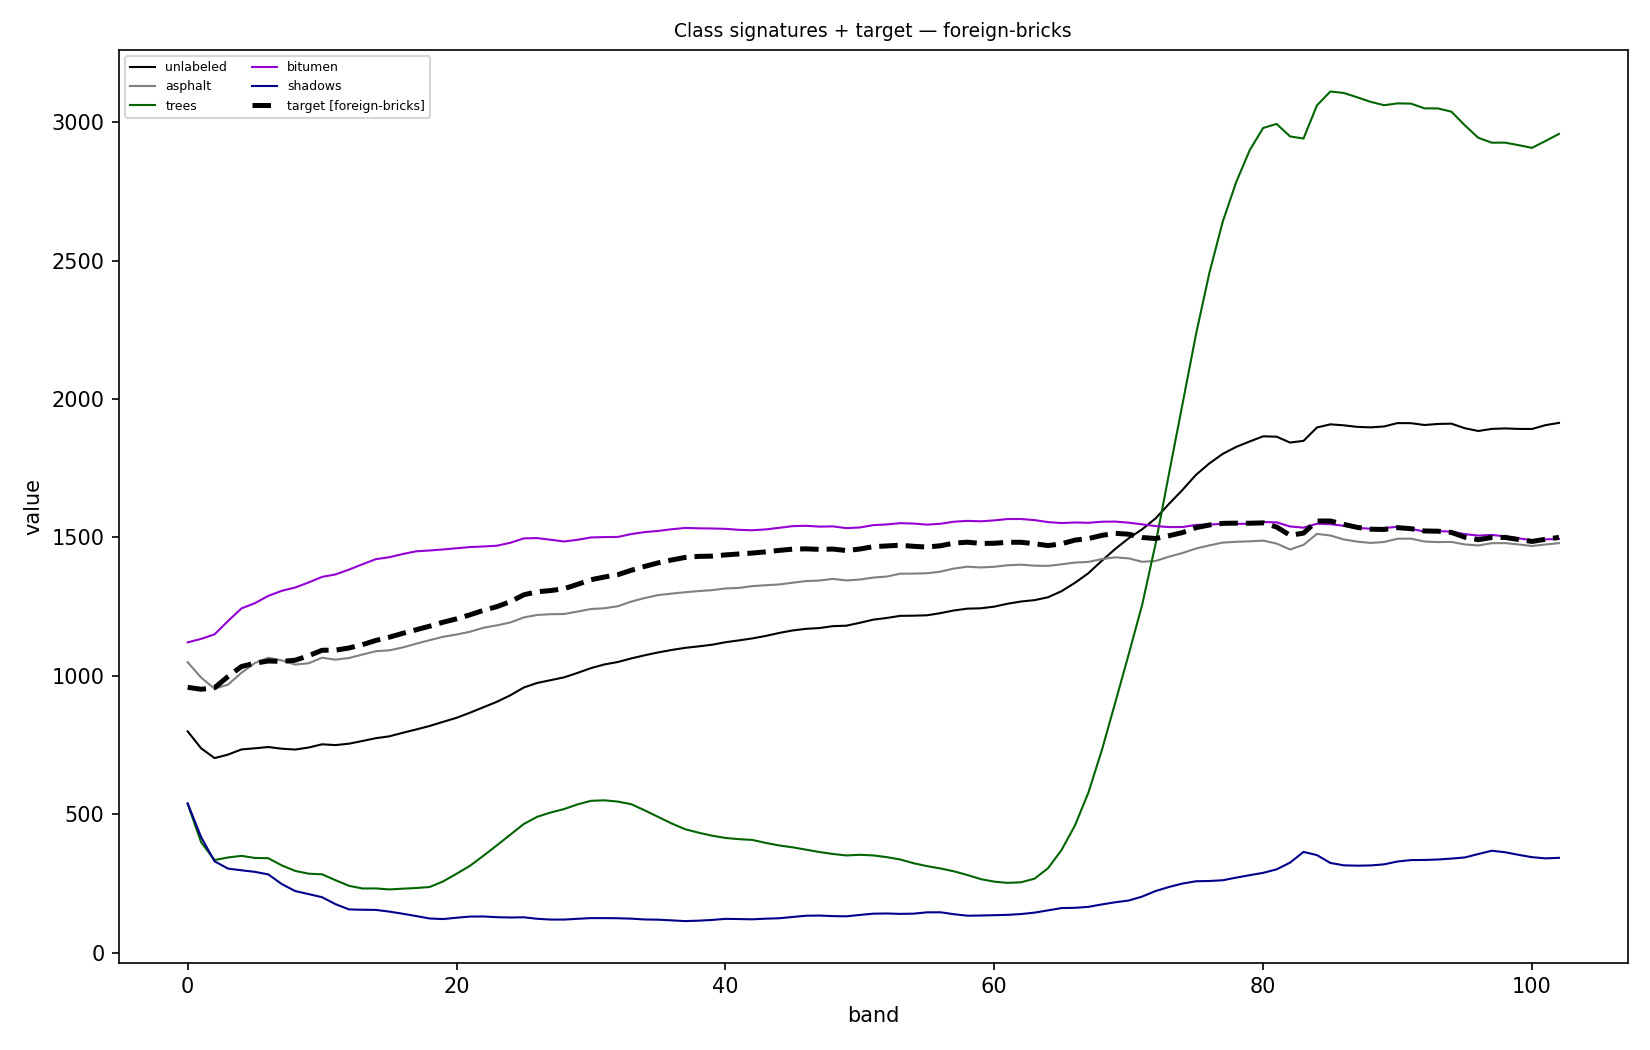

── detection_maps.png ──


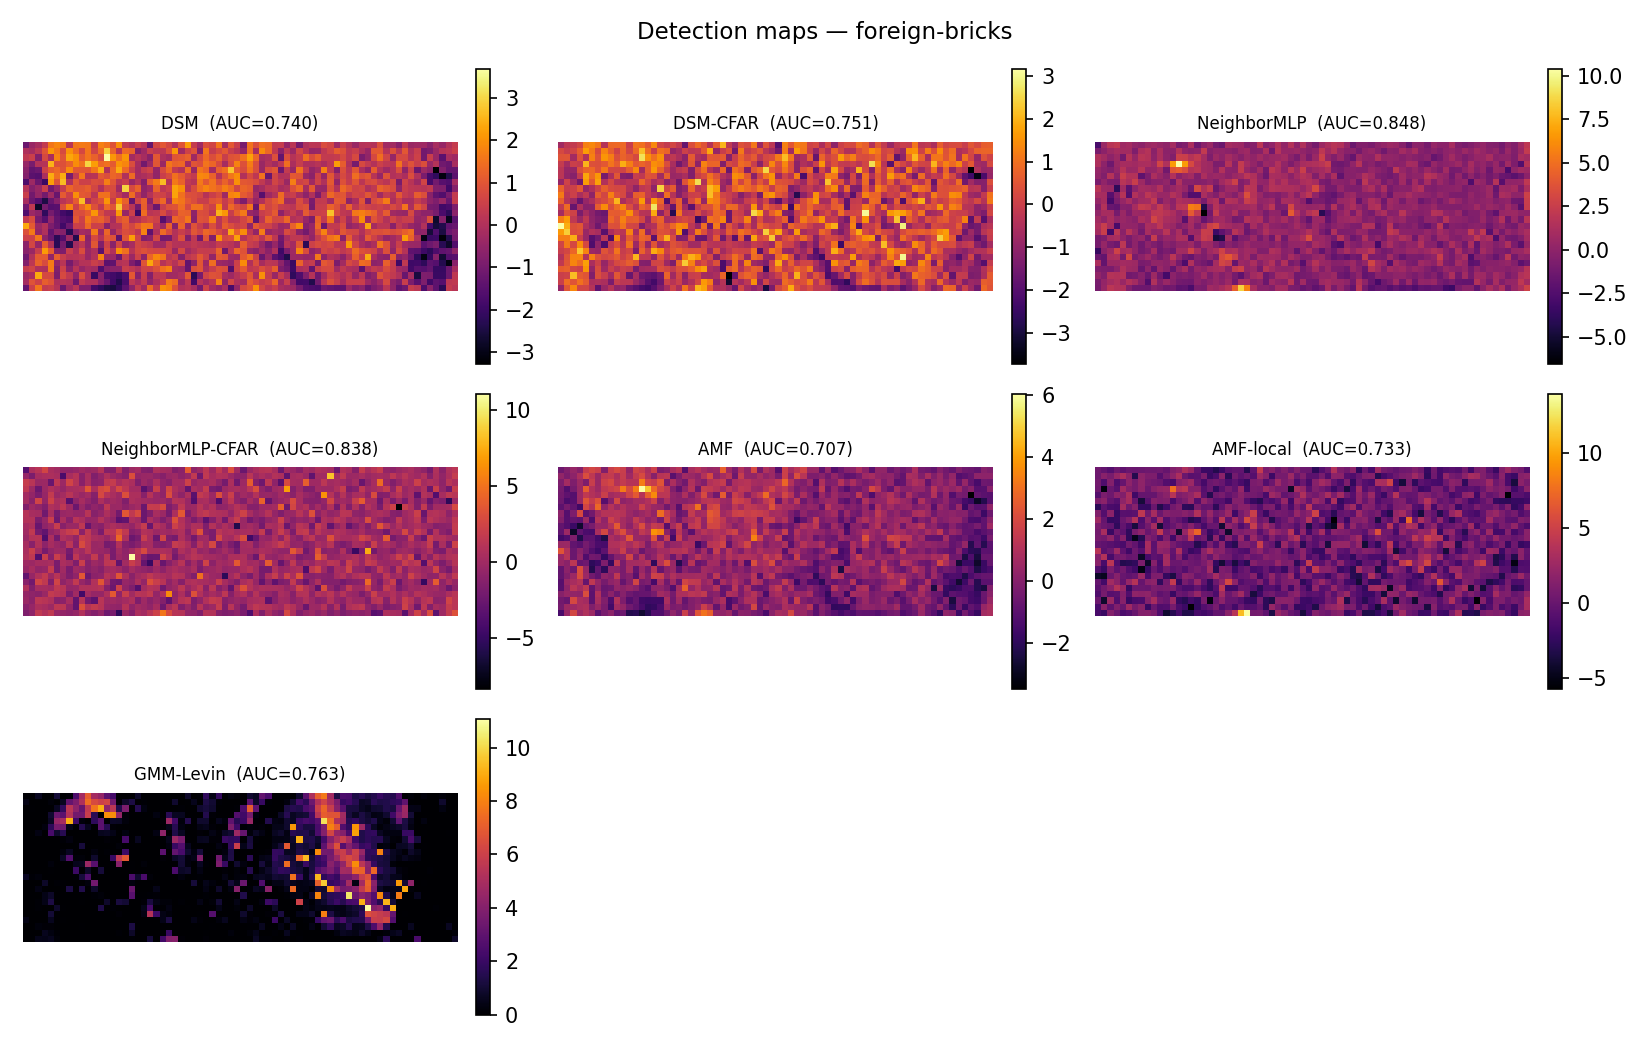

── detected_pfa.png ──


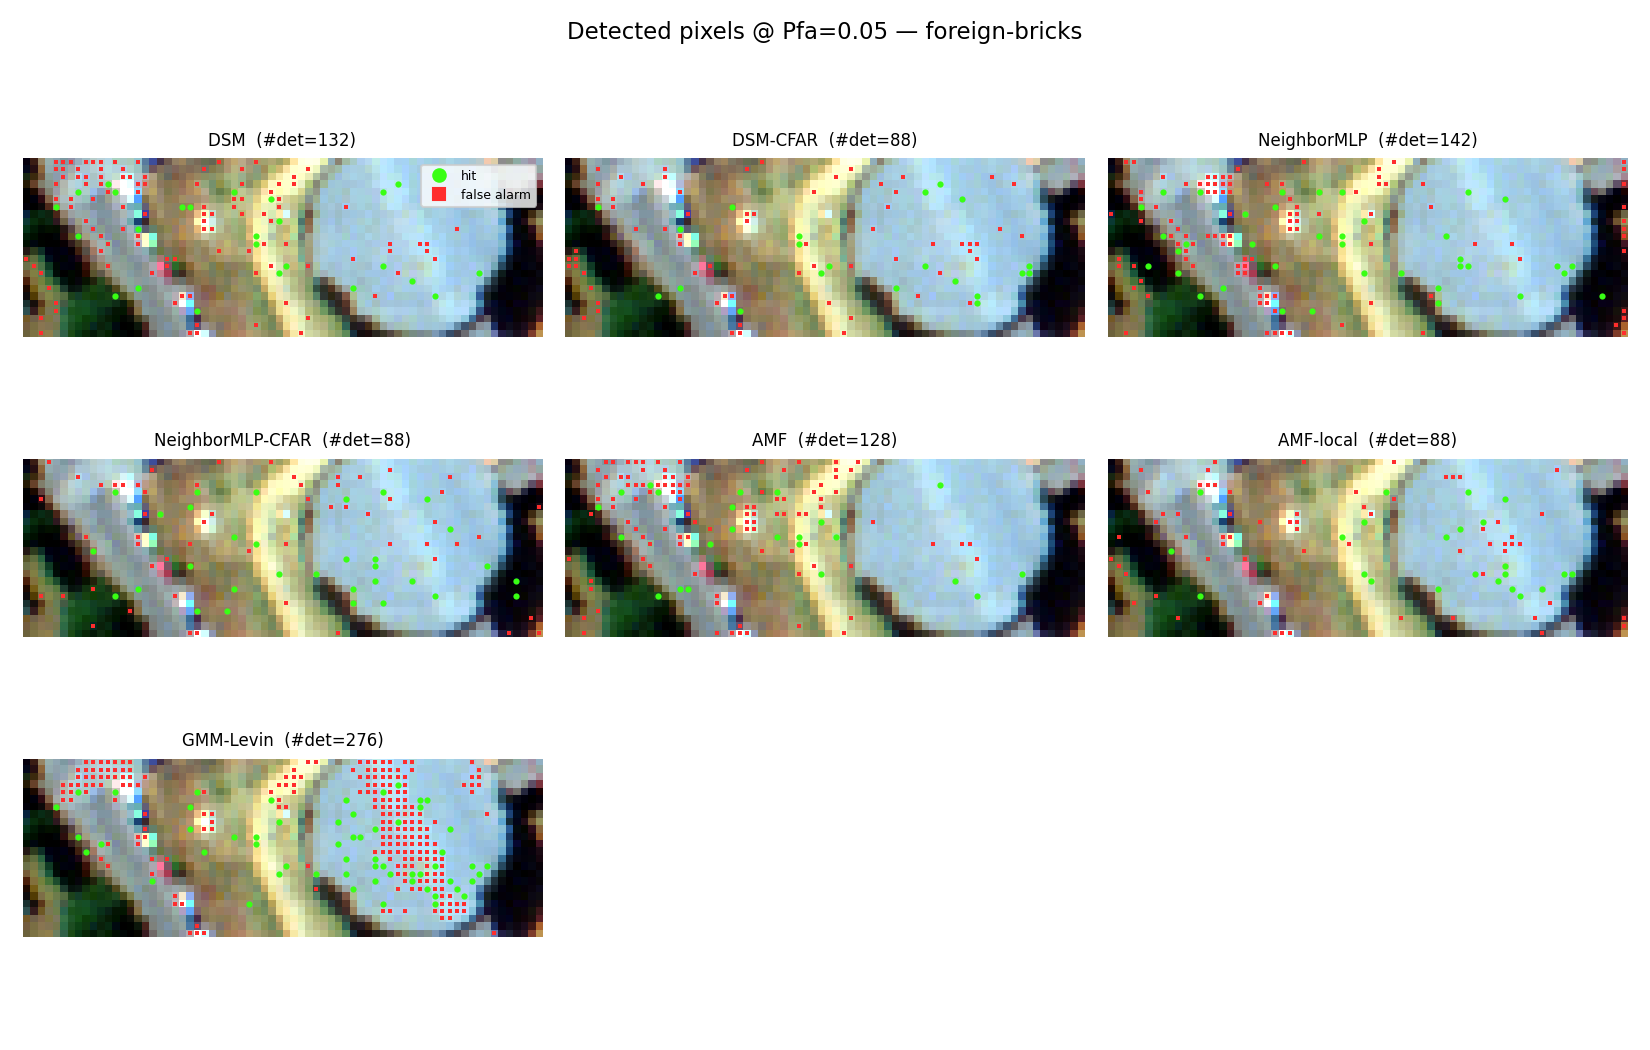

── roc.png ──


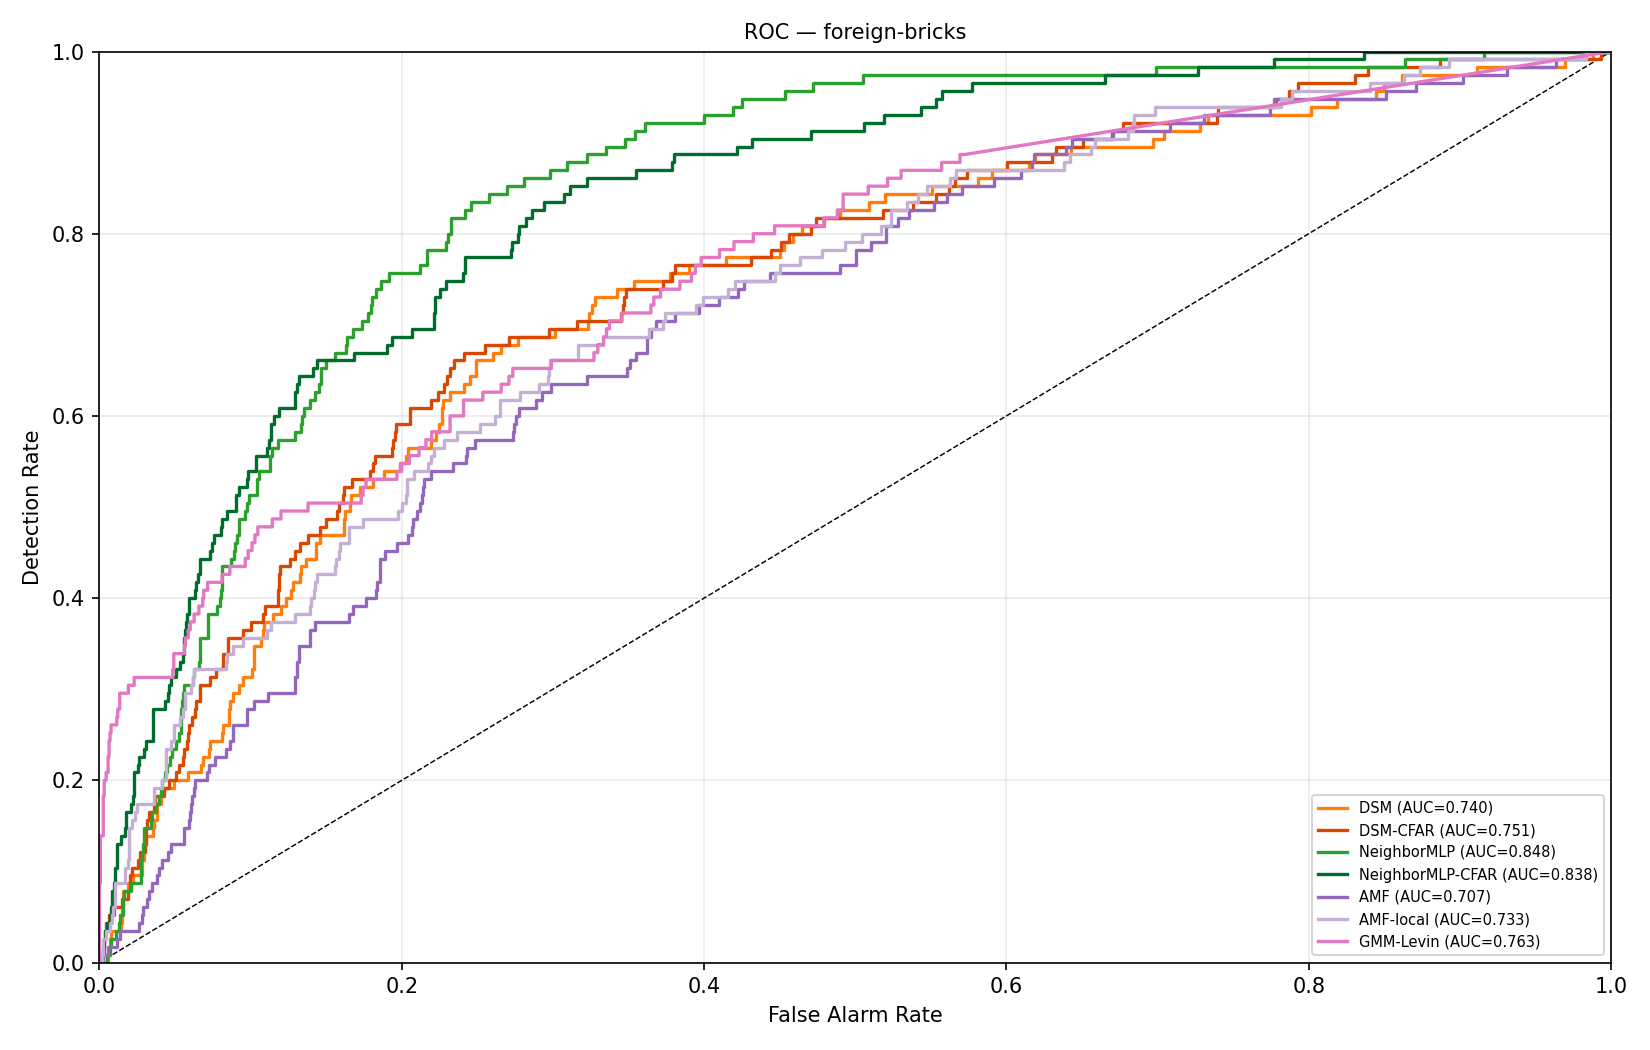

── pfa_per_class.png ──


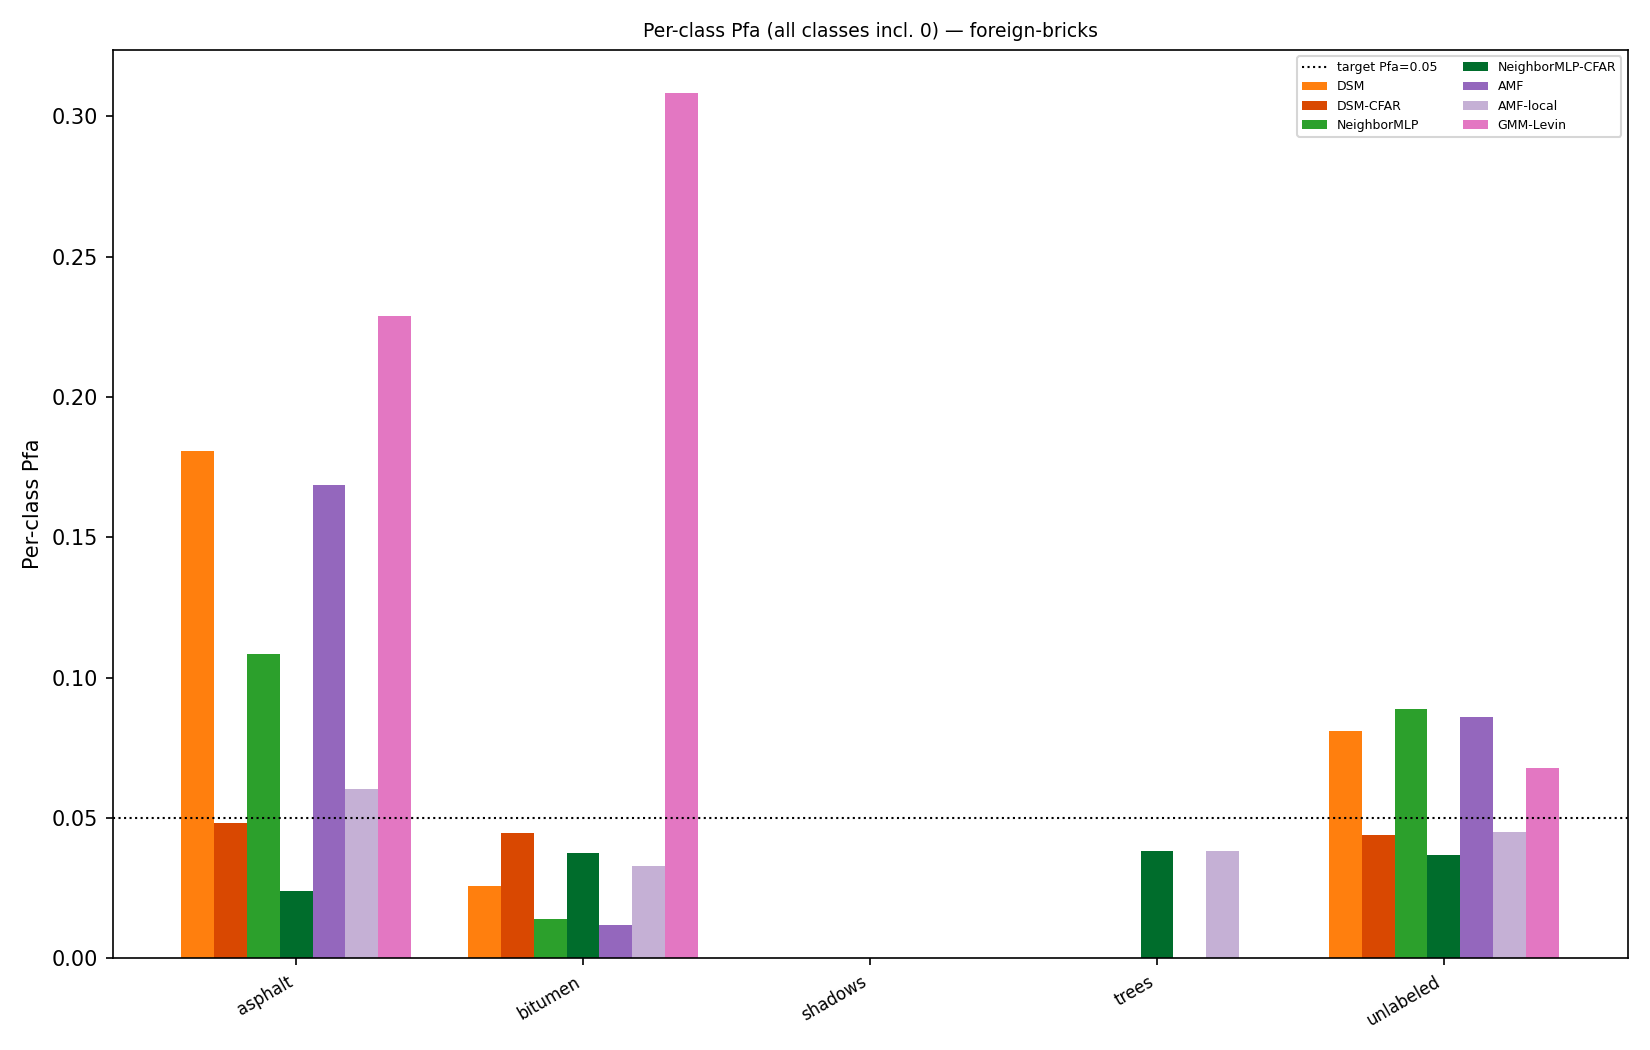

── false_alarms_falsecolor.png ──


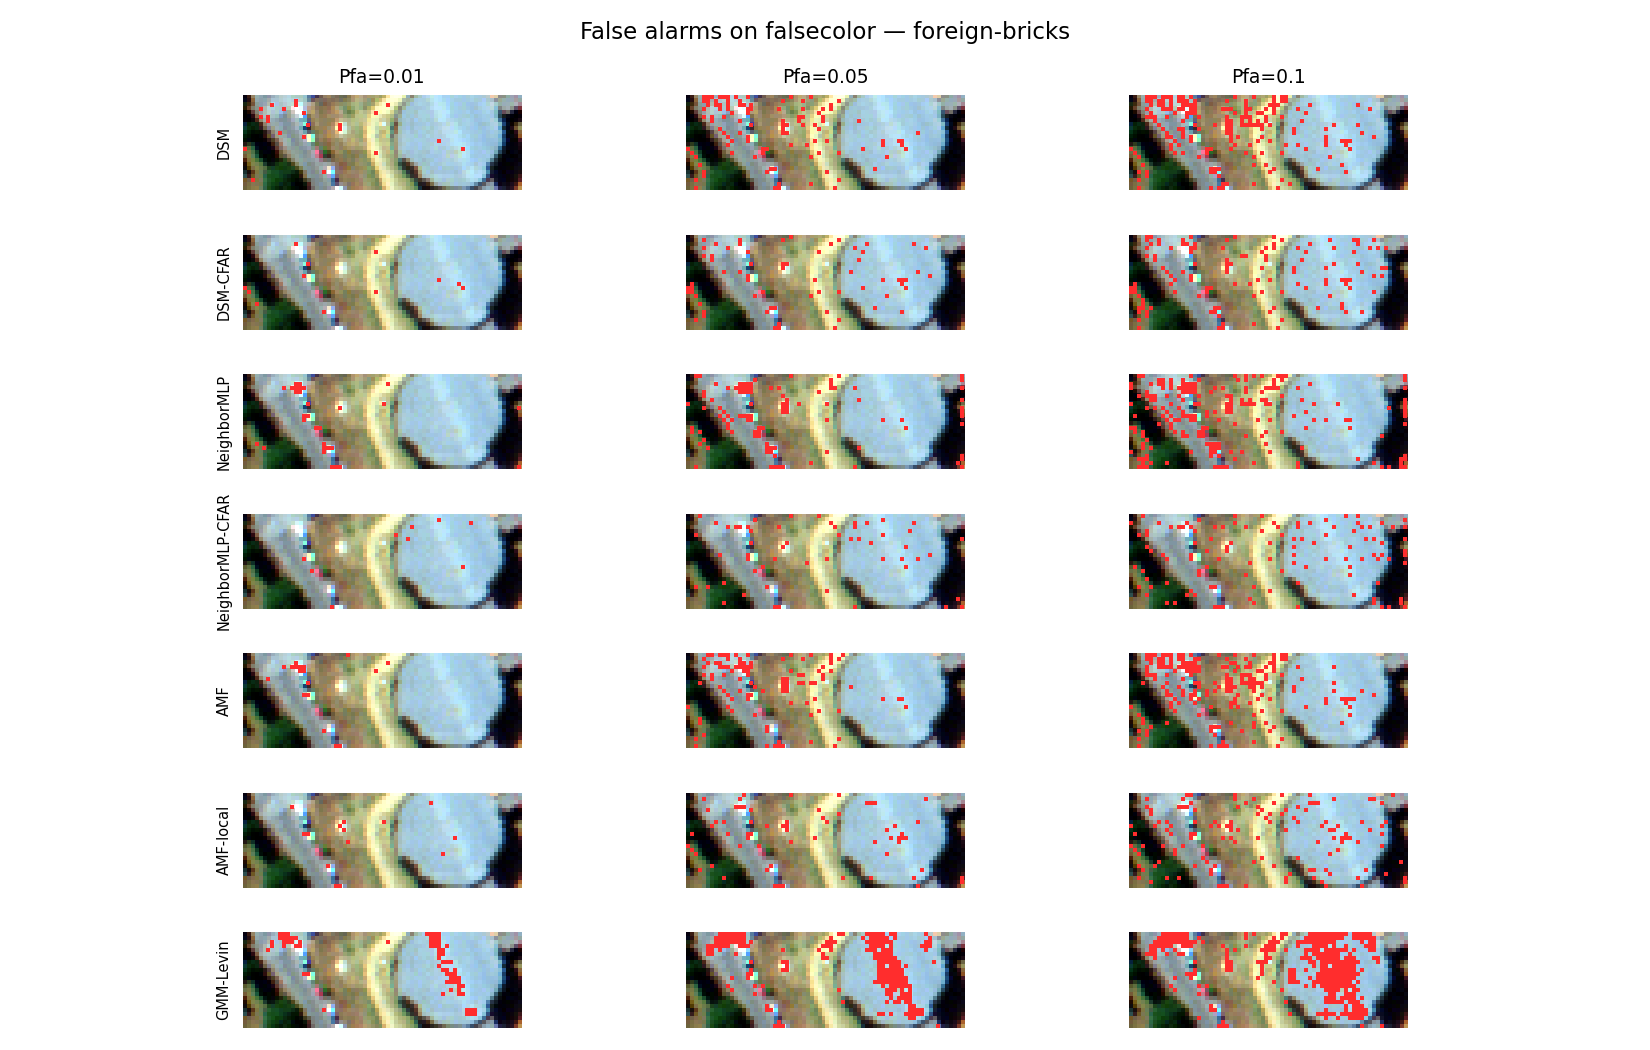

── false_alarms_labelmap.png ──


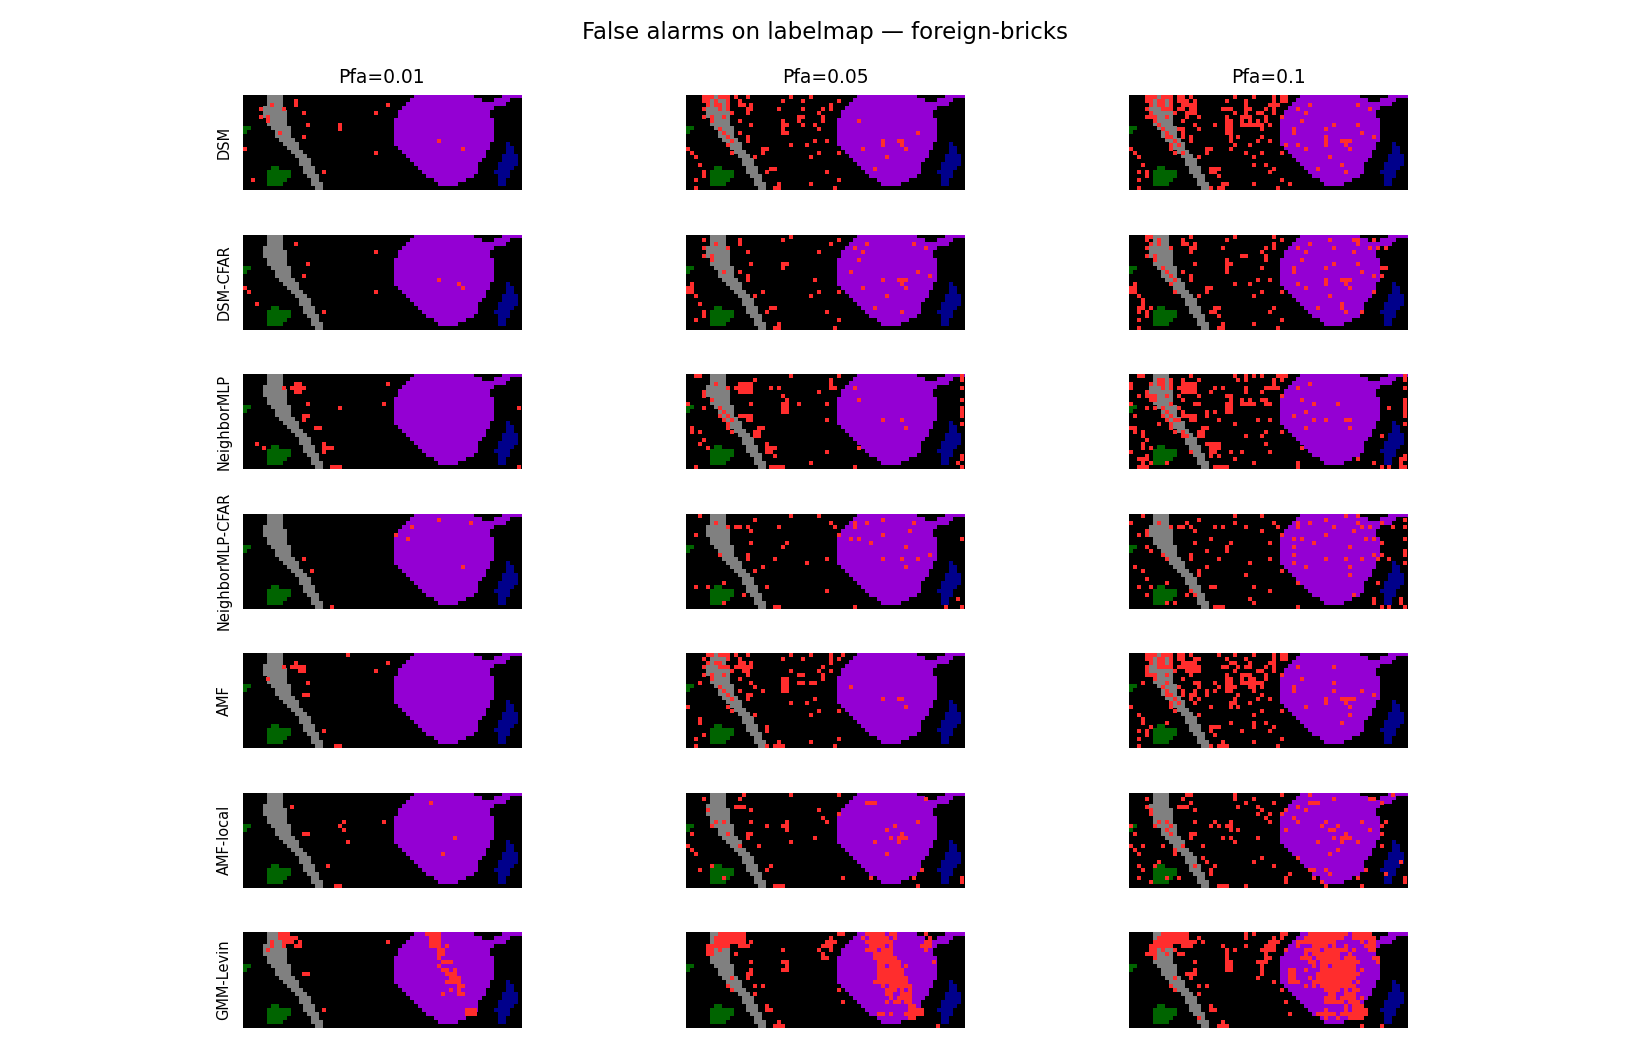


=== Summary Table ===
| Detector | pAUC@0.05 | AUC | Pd@Pfa=0.05 | Pd_cfar | Pfa_avg | Pfa_max | Pfa[unlabeled] | Pfa[asphalt] | Pfa[trees] | Pfa[bitumen] | Pfa[shadows] |
|---|---|---|---|---|---|---|---|---|---|---|---|
| DSM | 0.101 | 0.740 | 0.200 | 0.217 | 0.058 | 0.181 | 0.081 | 0.181 | 0.000 | 0.026 | 0.000 |
| DSM-CFAR | 0.113 | 0.751 | 0.200 | 0.183 | 0.027 | 0.048 | 0.044 | 0.048 | 0.000 | 0.045 | 0.000 |
| NeighborMLP | 0.107 | 0.848 | 0.235 | 0.330 | 0.042 | 0.108 | 0.089 | 0.108 | 0.000 | 0.014 | 0.000 |
| NeighborMLP-CFAR | 0.187 | 0.838 | 0.313 | 0.278 | 0.027 | 0.038 | 0.037 | 0.024 | 0.038 | 0.038 | 0.000 |
| AMF | 0.056 | 0.707 | 0.130 | 0.200 | 0.053 | 0.169 | 0.086 | 0.169 | 0.000 | 0.012 | 0.000 |
| AMF-local | 0.138 | 0.733 | 0.261 | 0.200 | 0.035 | 0.060 | 0.045 | 0.060 | 0.038 | 0.033 | 0.000 |
| GMM-Levin | 0.286 | 0.763 | 0.339 | 0.504 | 0.121 | 0.308 | 0.068 | 0.229 | 0.000 | 0.308 | 0.000 |



In [7]:
# ── Scenario 0 — manual box 0 ─────────────────────────────────────────
# dominant in scene = bitumen
# FOREIGN candidates (classes ABSENT from this scene — pick one as foreign_class):
#   2=meadows, 3=gravel, 5=metal_sheets, 6=bare_soil, 8=bricks
ov = dict(BASE)
ov['scenario_index'] = 0

# ── pick the foreign (out-of-scene) target ──
ov['foreign_class']  = 8     # ← change to any absent class id above

# ── per-scene tuning (uncomment to override BASE) ──
# ov['amplitude']        = 0.15
# ov['target_fraction']  = 0.10
# ov['k']                = 5
# ov['n_budget']         = None
# ov['nmlp_K']           = 7
# ov['active_detectors'] = ['NeighborMLP', 'NeighborMLP-CFAR', 'AMF', 'GMM-Levin']

# runs all SEEDS, aggregates to a mean±std table + bar figures
ms_dir_0 = run_seeds_and_show(ov, seeds=SEEDS)

## Scenario 2 — manual box 2


########## MULTI-SEED  seeds=[42, 43, 44, 45, 46]  -> /content/drive/MyDrive/final_paper/spatial_results/multiseed_20260612_182529

===== seed 42  (1/5) =====
Device: cuda
Loading data ...
Image 610×340×103
Scenario 2: train_box=[47, 114, 81, 139]  test_box=[121, 141, 79, 156]
train=3886 px  (box [47, 114, 81, 139])
test=1540 px  (20×77)
AMF-local window=15×15 (independent of k=5)
in-patch signature: dominant=trees  ||s||=2.066e+04
foreign signature: class=bitumen  scaled ||s||=1.953e+04
Training DSM ...


DSM:   0%|          | 0/1000 [00:00<?, ?it/s, loss=2058.4435]

    [DSM] epoch 1/1000  loss=2058.4435  best=2058.4435


DSM:  10%|▉         | 98/1000 [00:03<00:25, 35.84it/s, loss=1730.2512]

    [DSM] epoch 100/1000  loss=1730.2512  best=1728.6353


...

    [NeighborMLP] epoch 900/1000  loss=1687.5398  best=1683.5657


NeighborMLP: 100%|█████████▉| 998/1000 [00:30<00:00, 35.43it/s, loss=1690.4295]

    [NeighborMLP] epoch 1000/1000  loss=1690.4295  best=1681.4894


  NeighborMLP done (30s)  best loss=1681.4894


  saved models -> /content/drive/MyDrive/final_paper/spatial_results/multiseed_20260612_182529/seeds/compare_20260612_183119/models.pt

########## DETECTION RUN: foreign-bitumen ##########
[foreign-bitumen] planted 99 targets  ||s||=1.953e+04
Scoring detectors (test) ...
Scoring detectors (train, for CFAR thresholds) ...
Active detectors: ['DSM', 'DSM-CFAR', 'NeighborMLP', 'NeighborMLP-CFAR', 'AMF', 'AMF-local', 'GMM-Levin']

=== Summary [foreign-bitumen] ===
| Detector | pAUC@0.05 | AUC | Pd@Pfa=0.05 | Pd_cfar | Pfa_avg | Pfa_max | Pfa[unlabeled] | Pfa[trees] |
|---|---|---|---|---|---|---|---|---|
| DSM | 0.116 | 0.776 | 0.263 | 0.768 | 0.220 | 0.357 | 0.357 | 0.083 |
| DSM-CFAR | 0.133 | 0.780 | 0.293 | 0.242 | 0.042 | 0.043 | 0.043 | 0.042 |
| NeighborMLP | 0.271 | 0.857 | 0.475 | 0.758 | 0.253 | 0.292 | 0.214 | 0.292 |
| NeighborMLP-CFAR | 0.205 | 0.835 | 0.354 | 0.253 | 0.036 | 0.042 | 0.030 | 0.042 |
| AMF | 0.050 | 0.739 | 0.111 | 0.788 | 0.330 | 0.410 | 0.410 | 0.250 |
| AMF-l

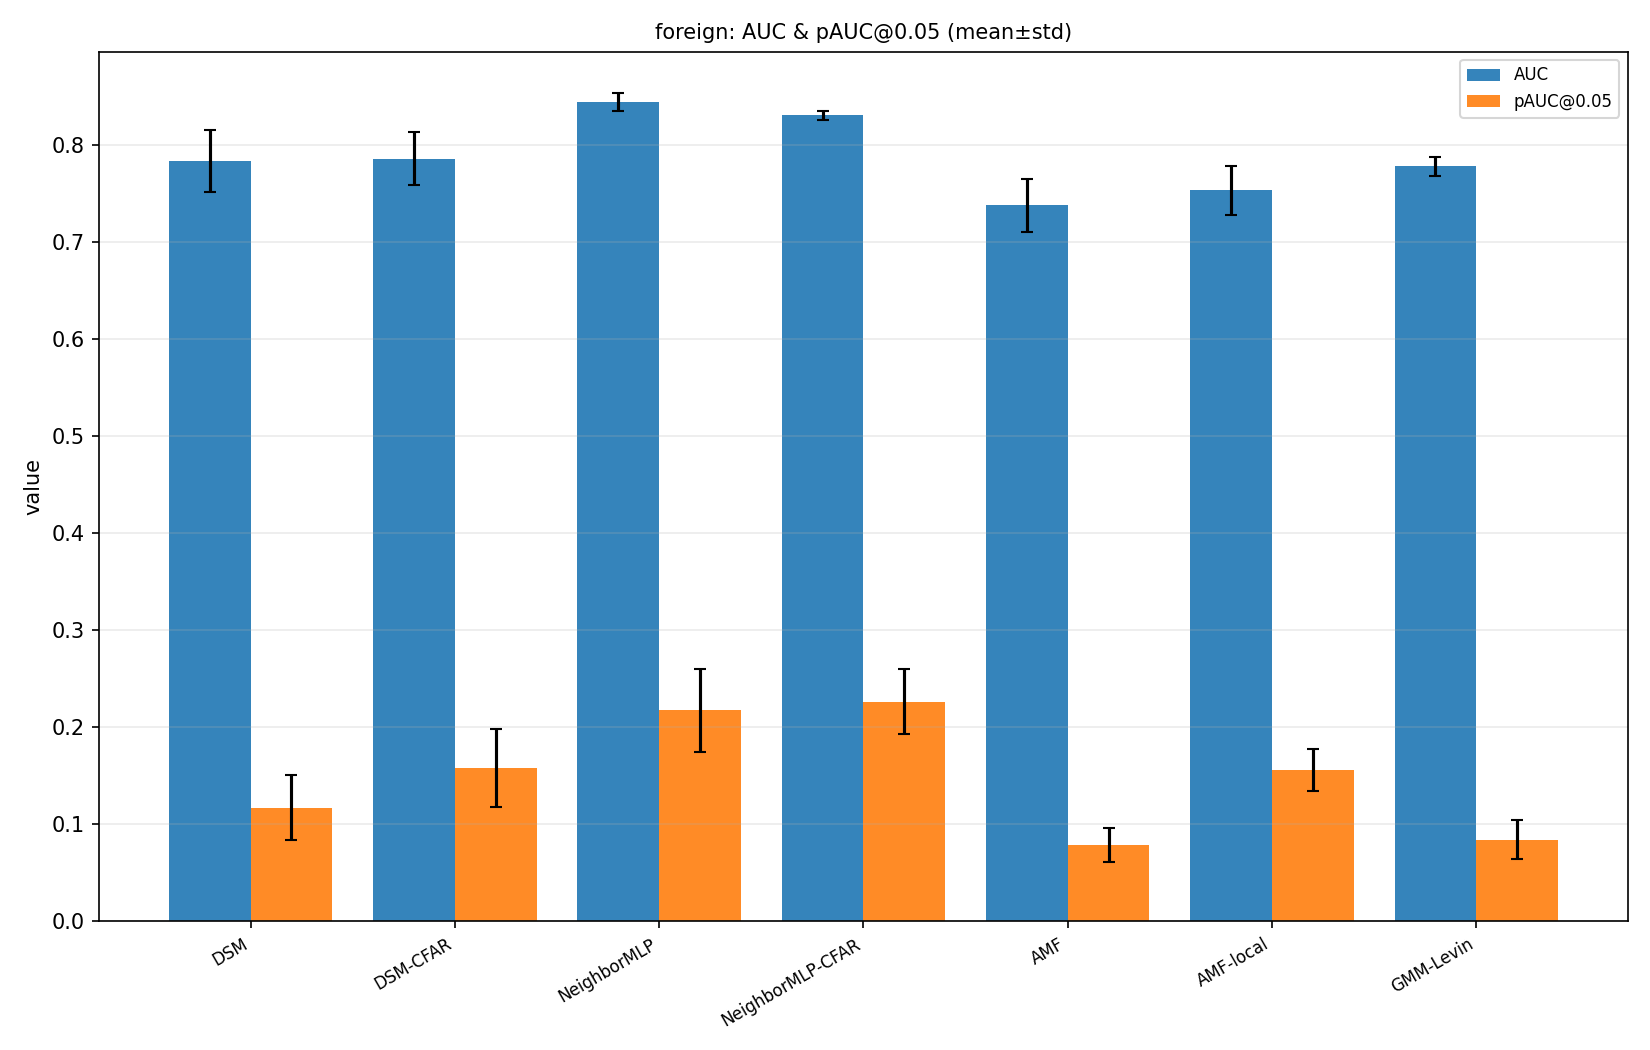

── foreign_pd_bar.png ──


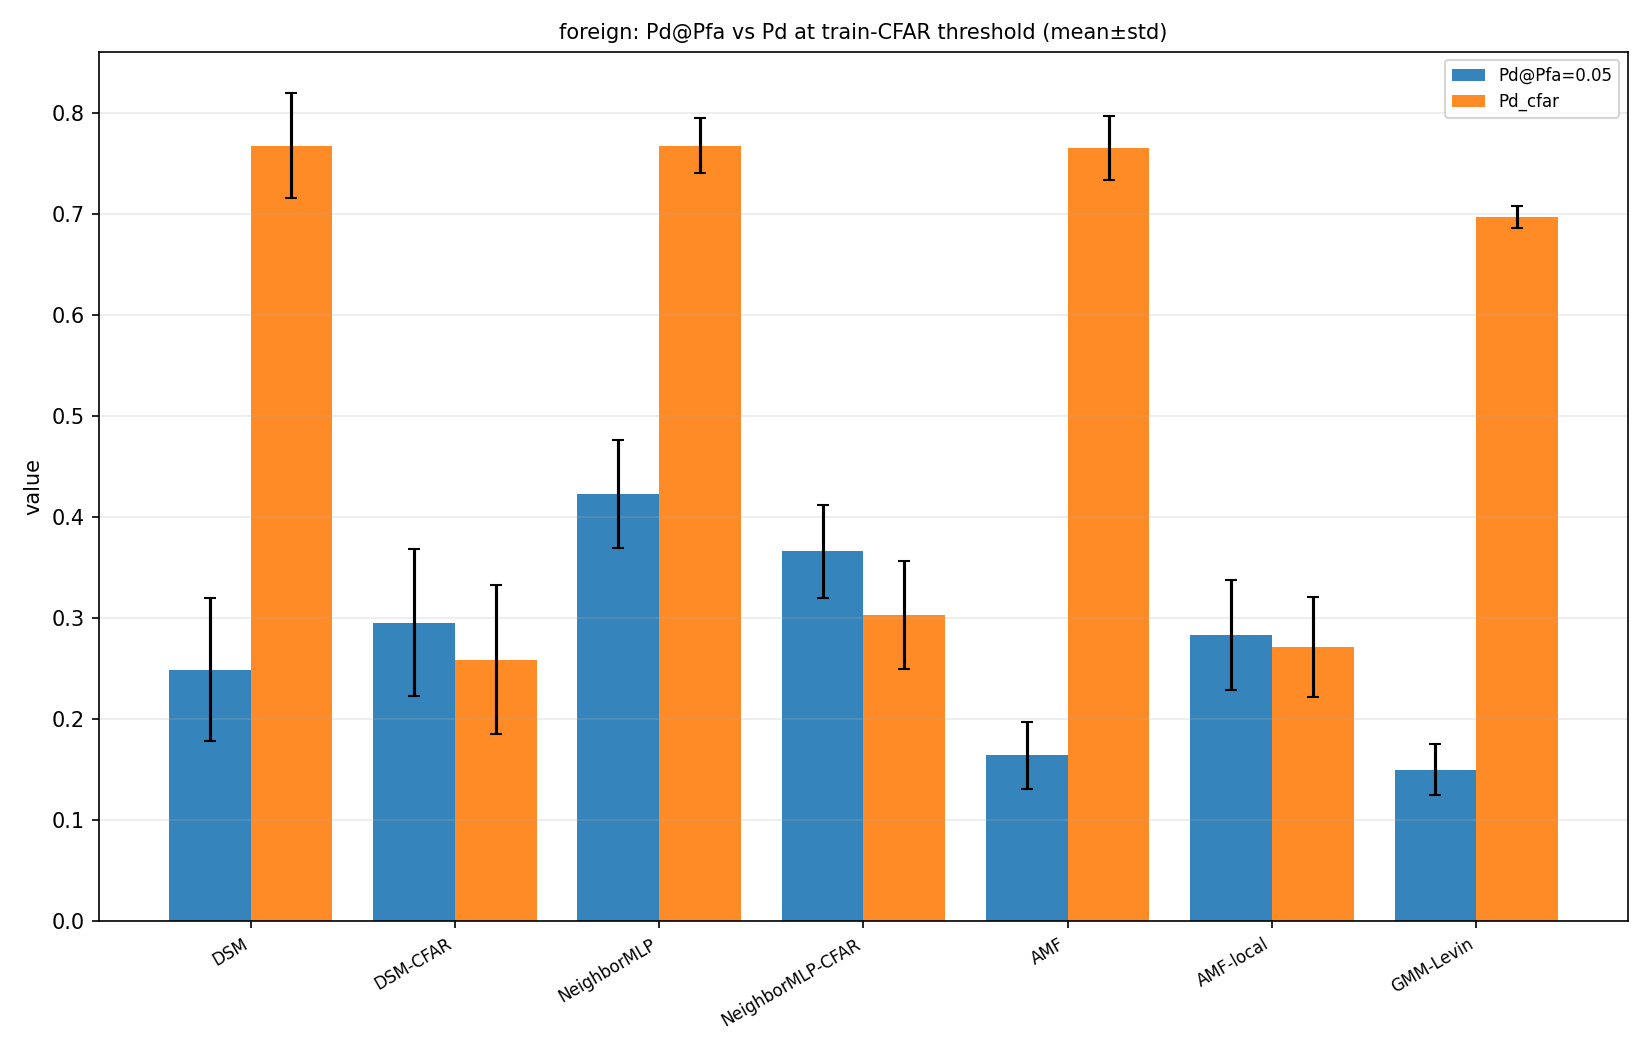

── foreign_pfa_bar.png ──


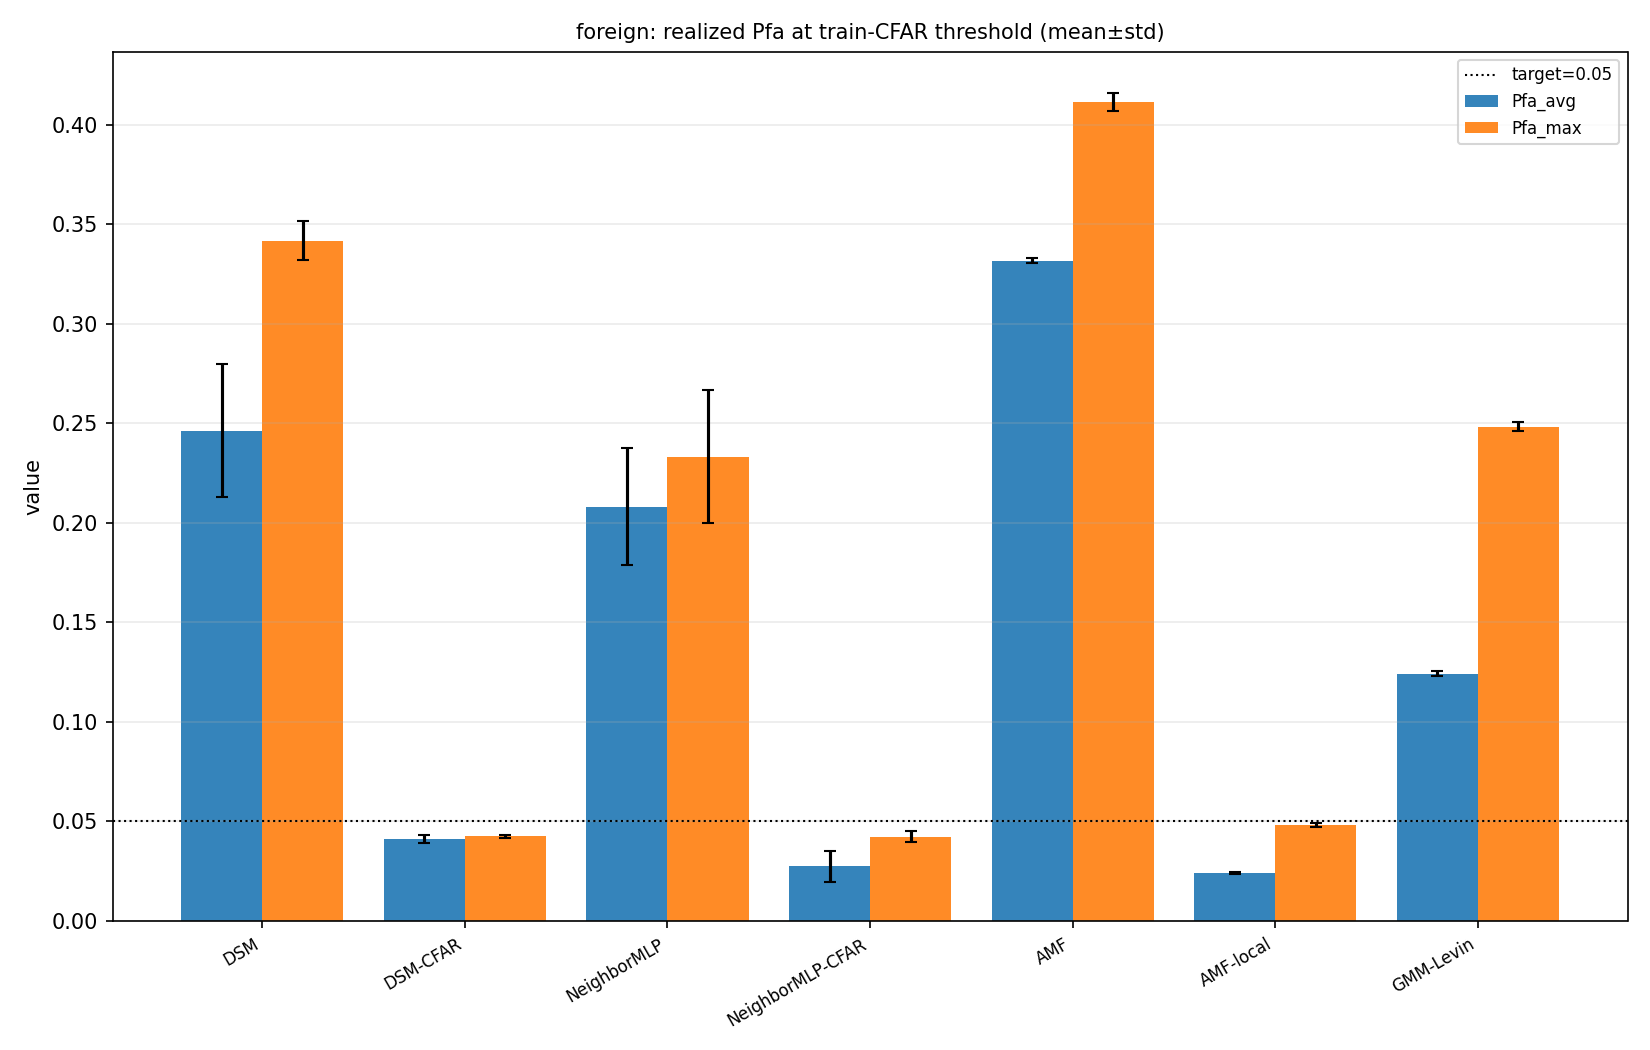


=== Representative qualitative figures (seed 42) ===
── false_color.png ──


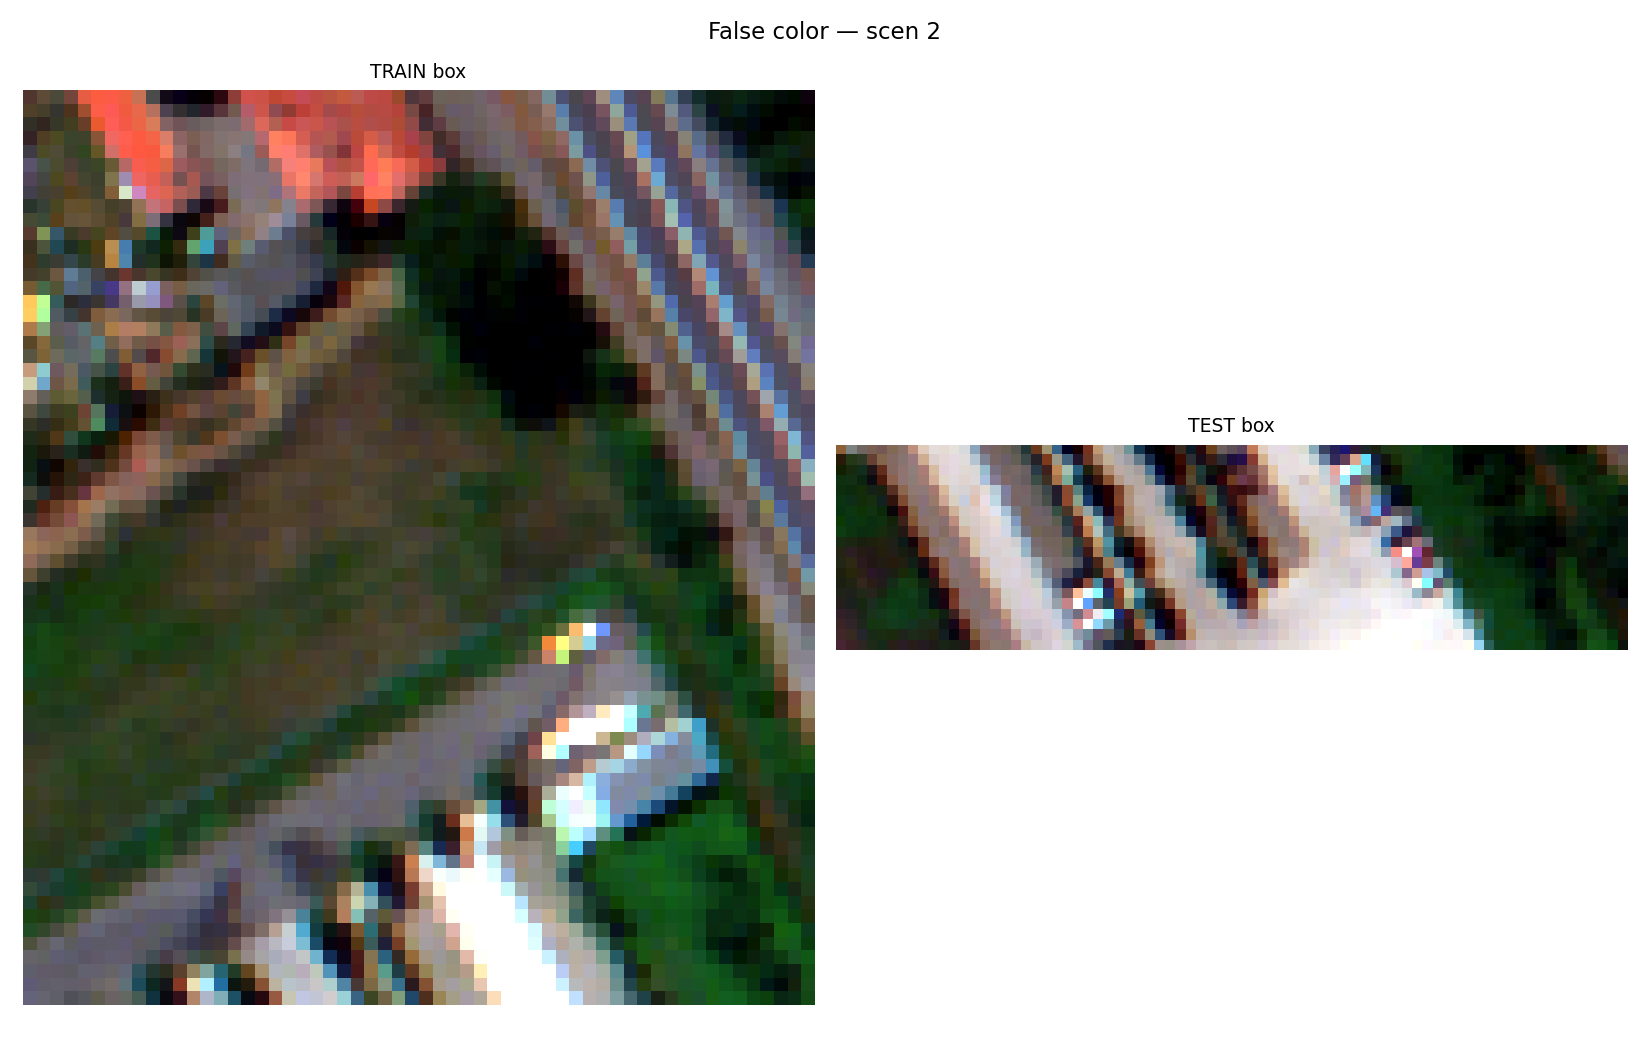

── label_map_targets.png ──


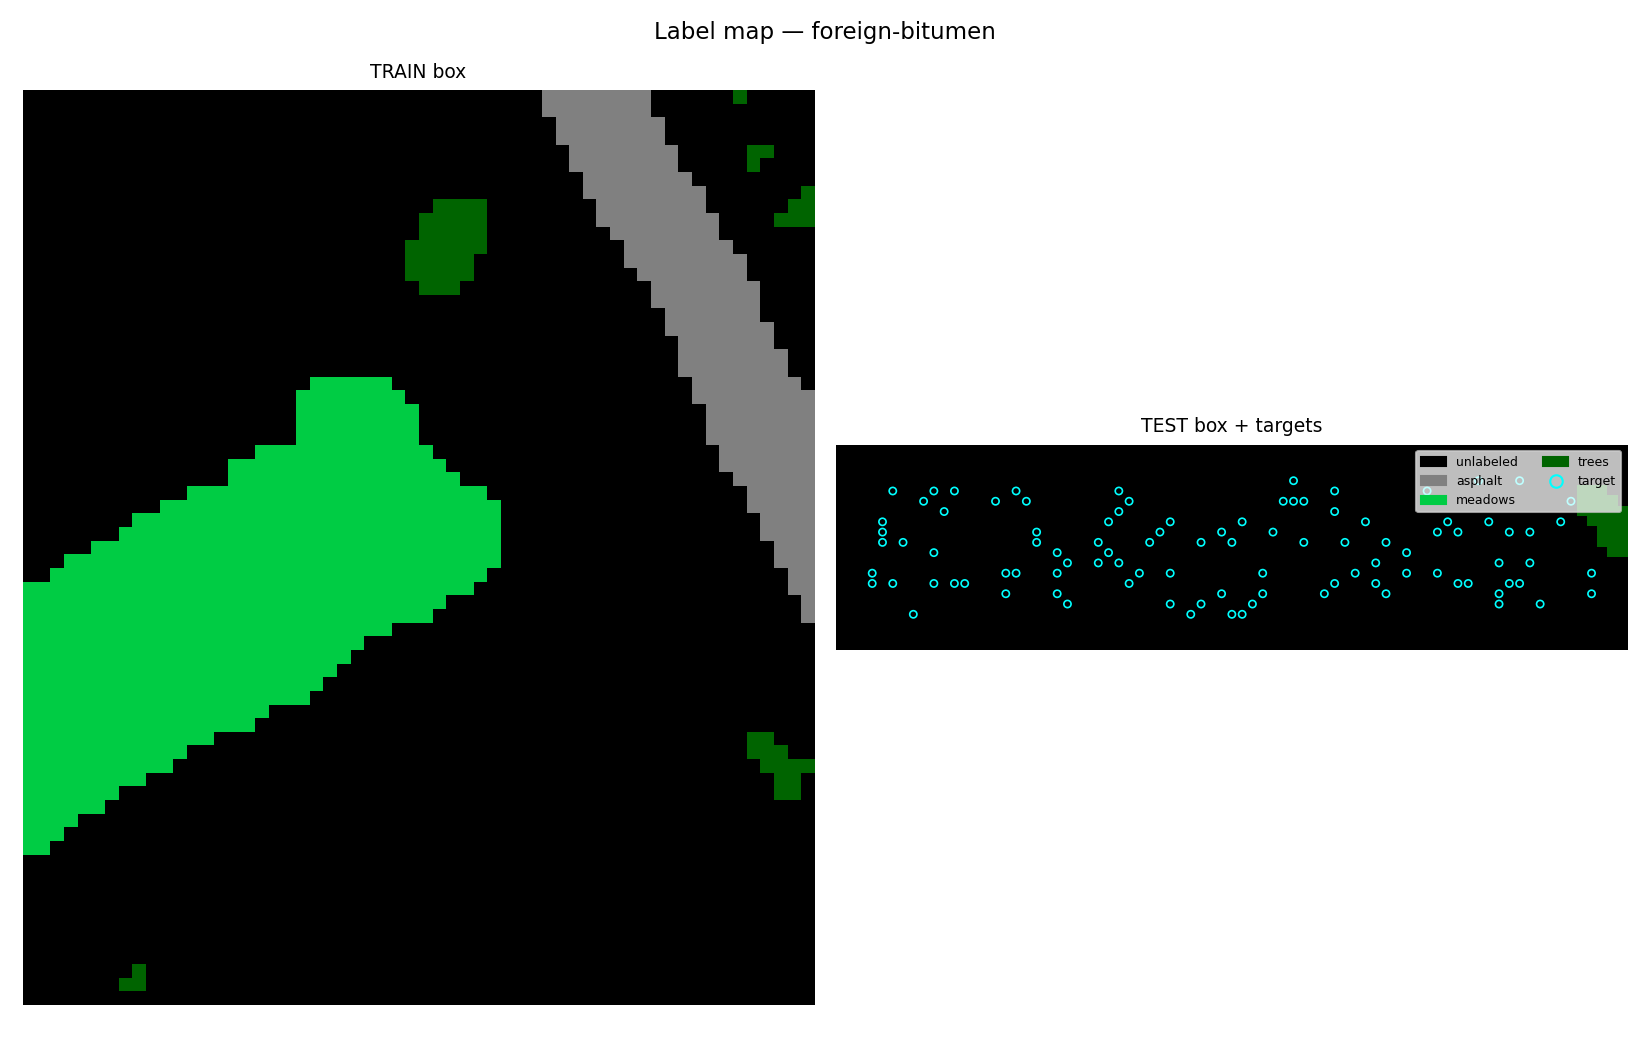

── signatures.png ──


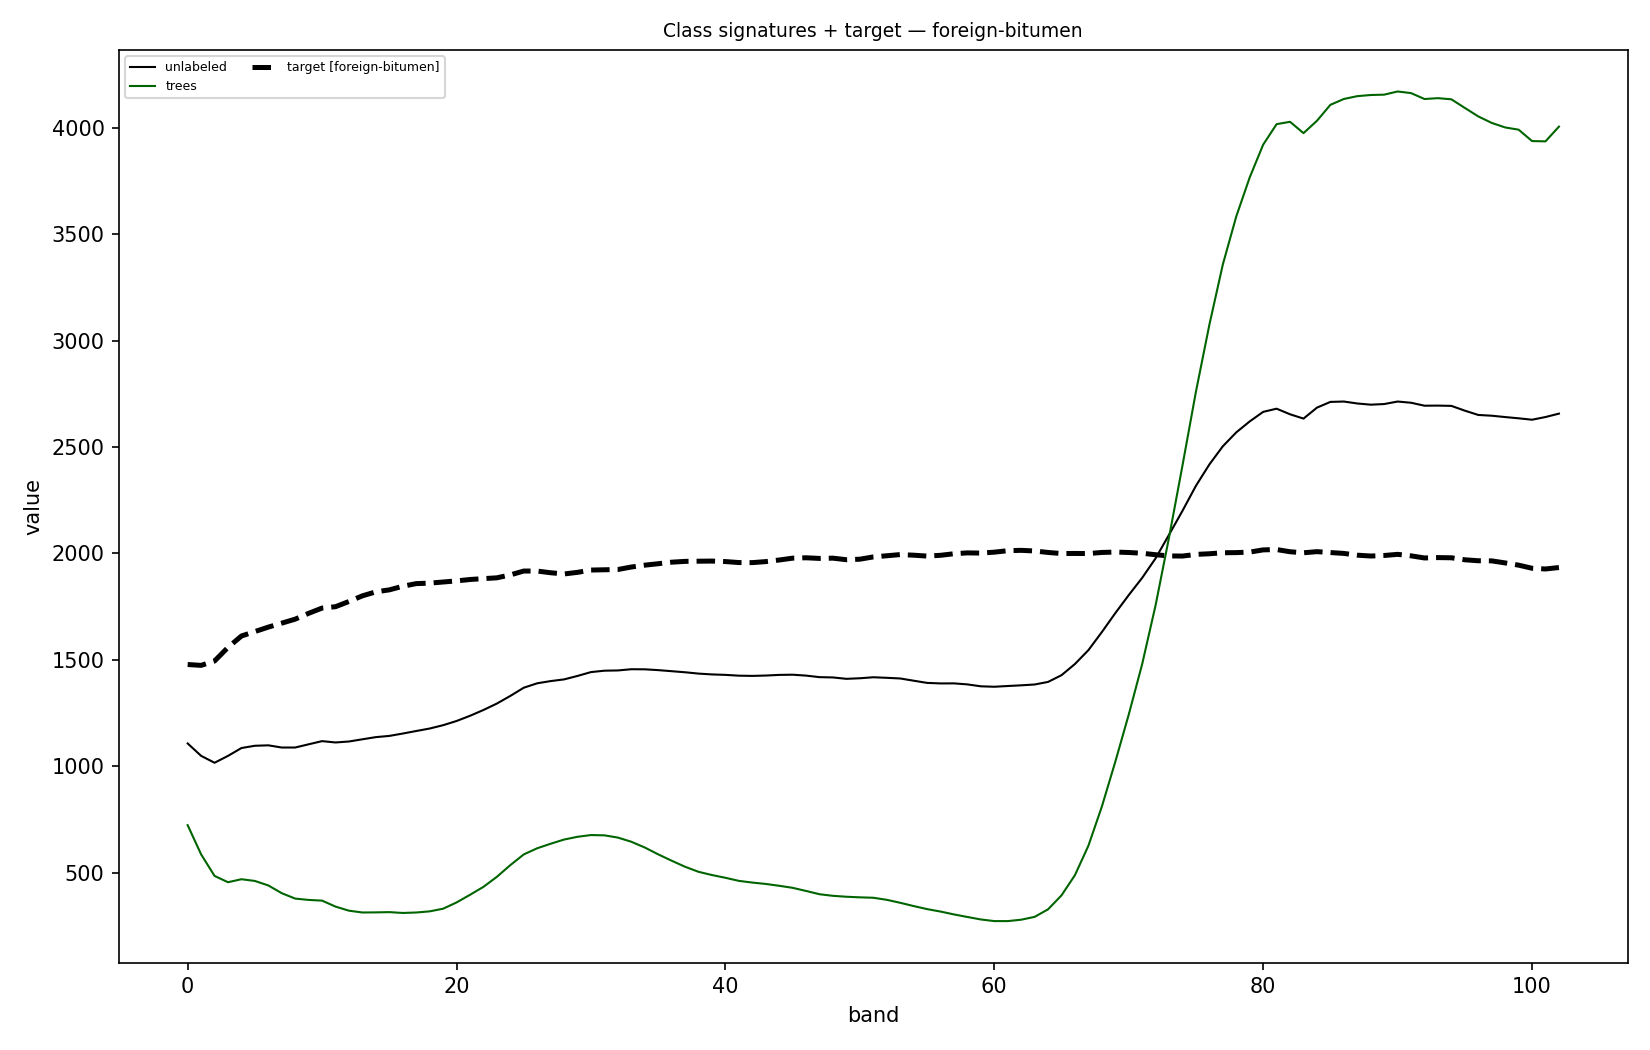

── detection_maps.png ──


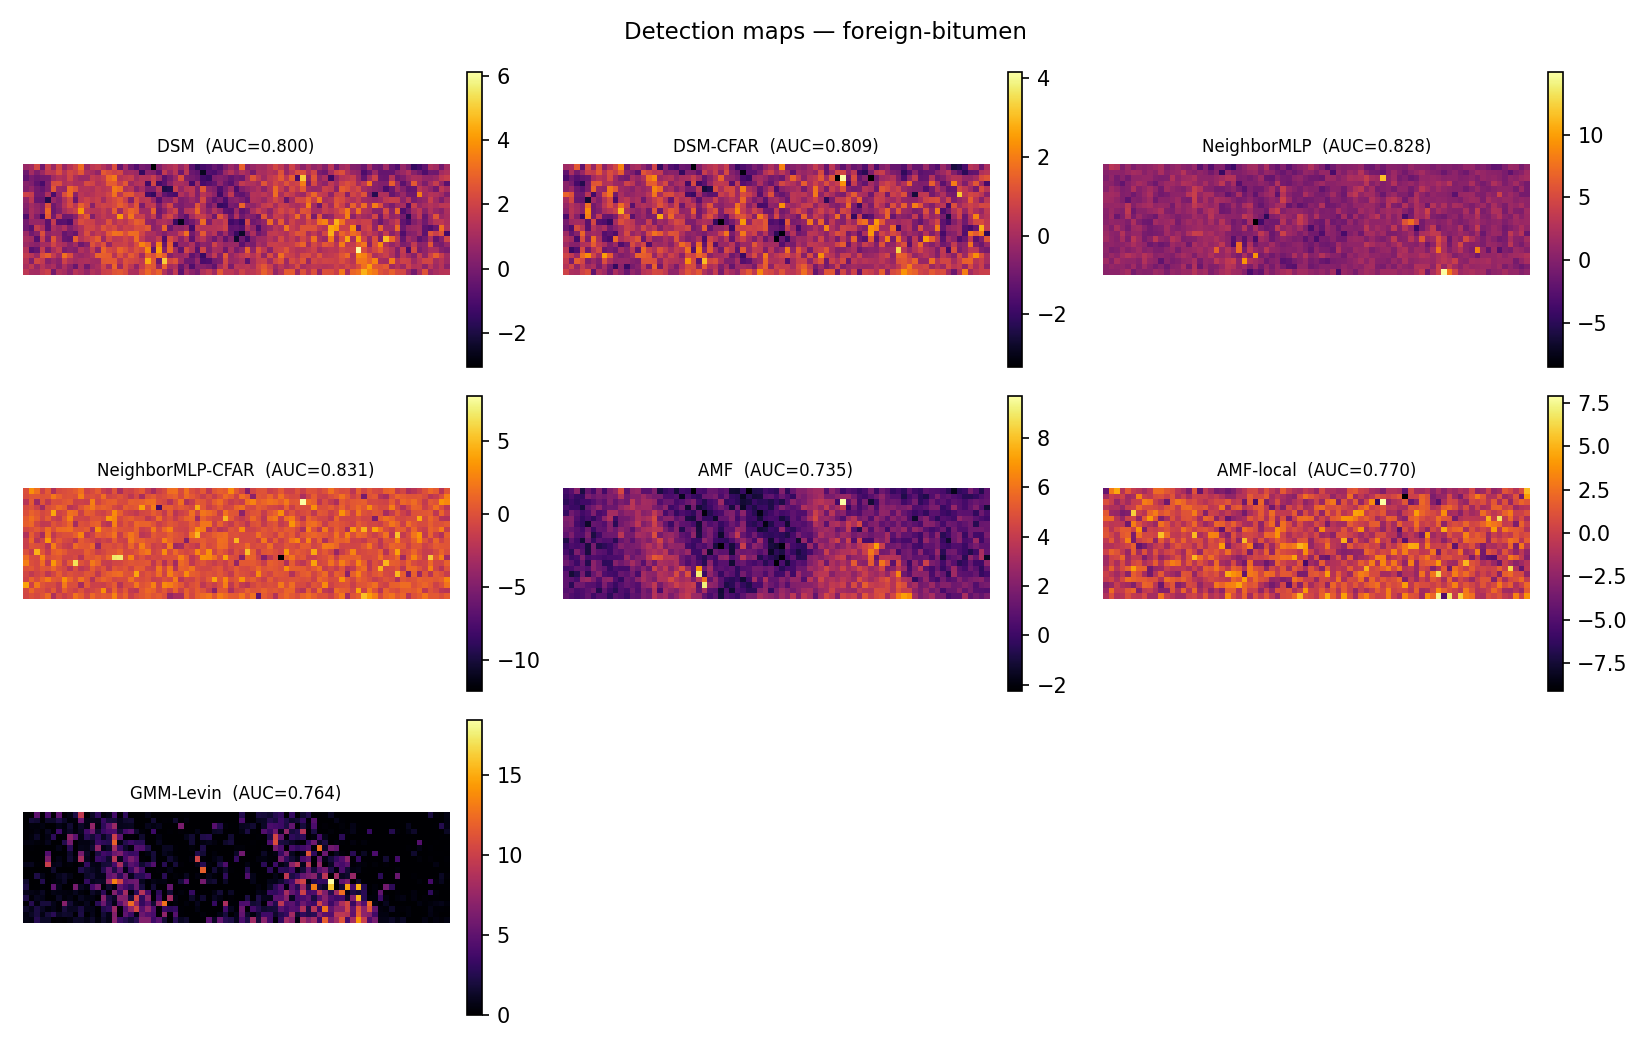

── detected_pfa.png ──


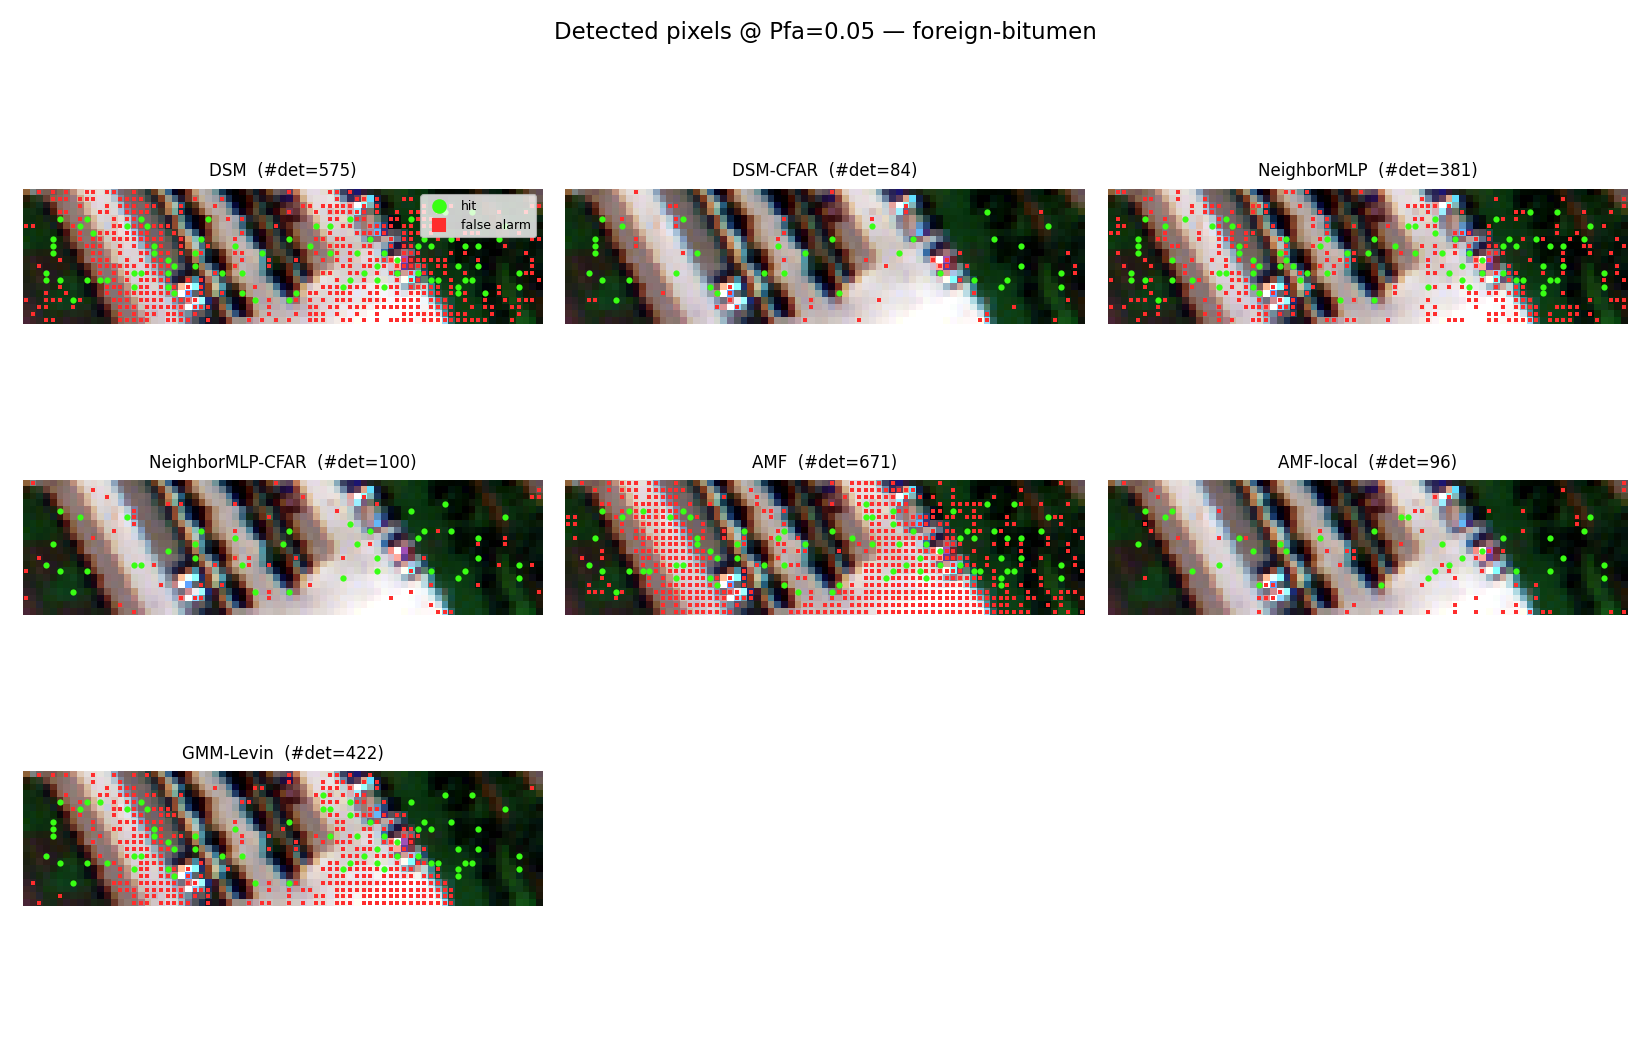

── roc.png ──


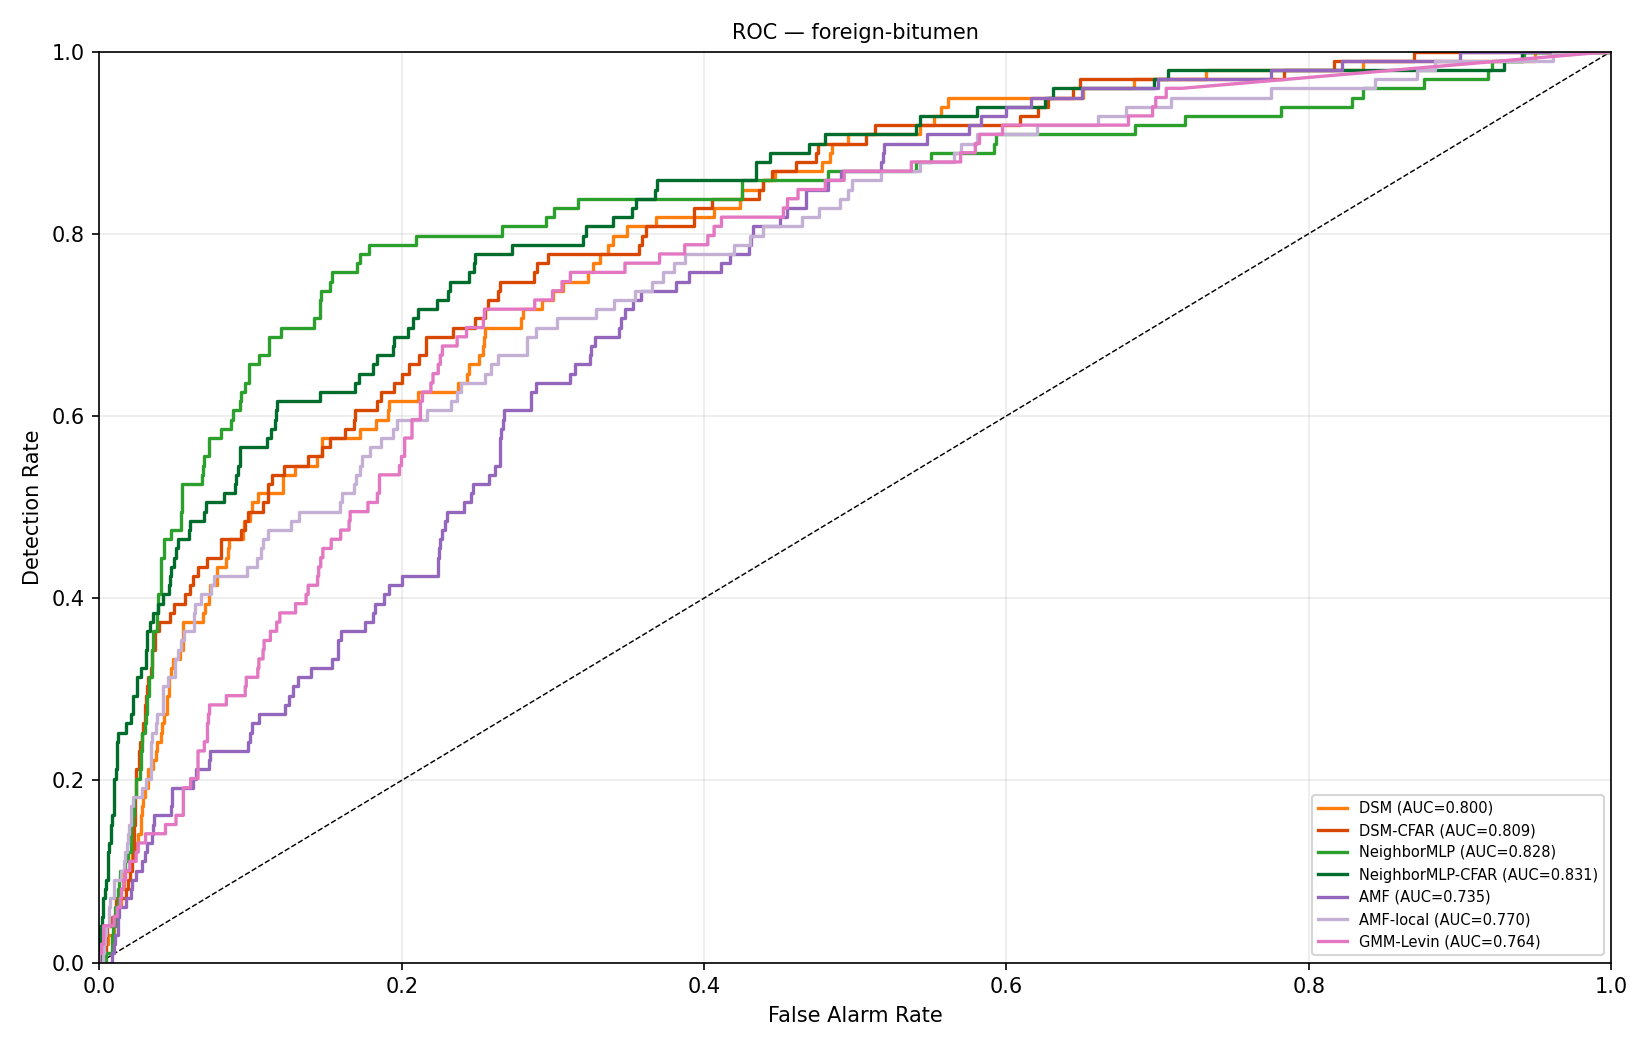

── pfa_per_class.png ──


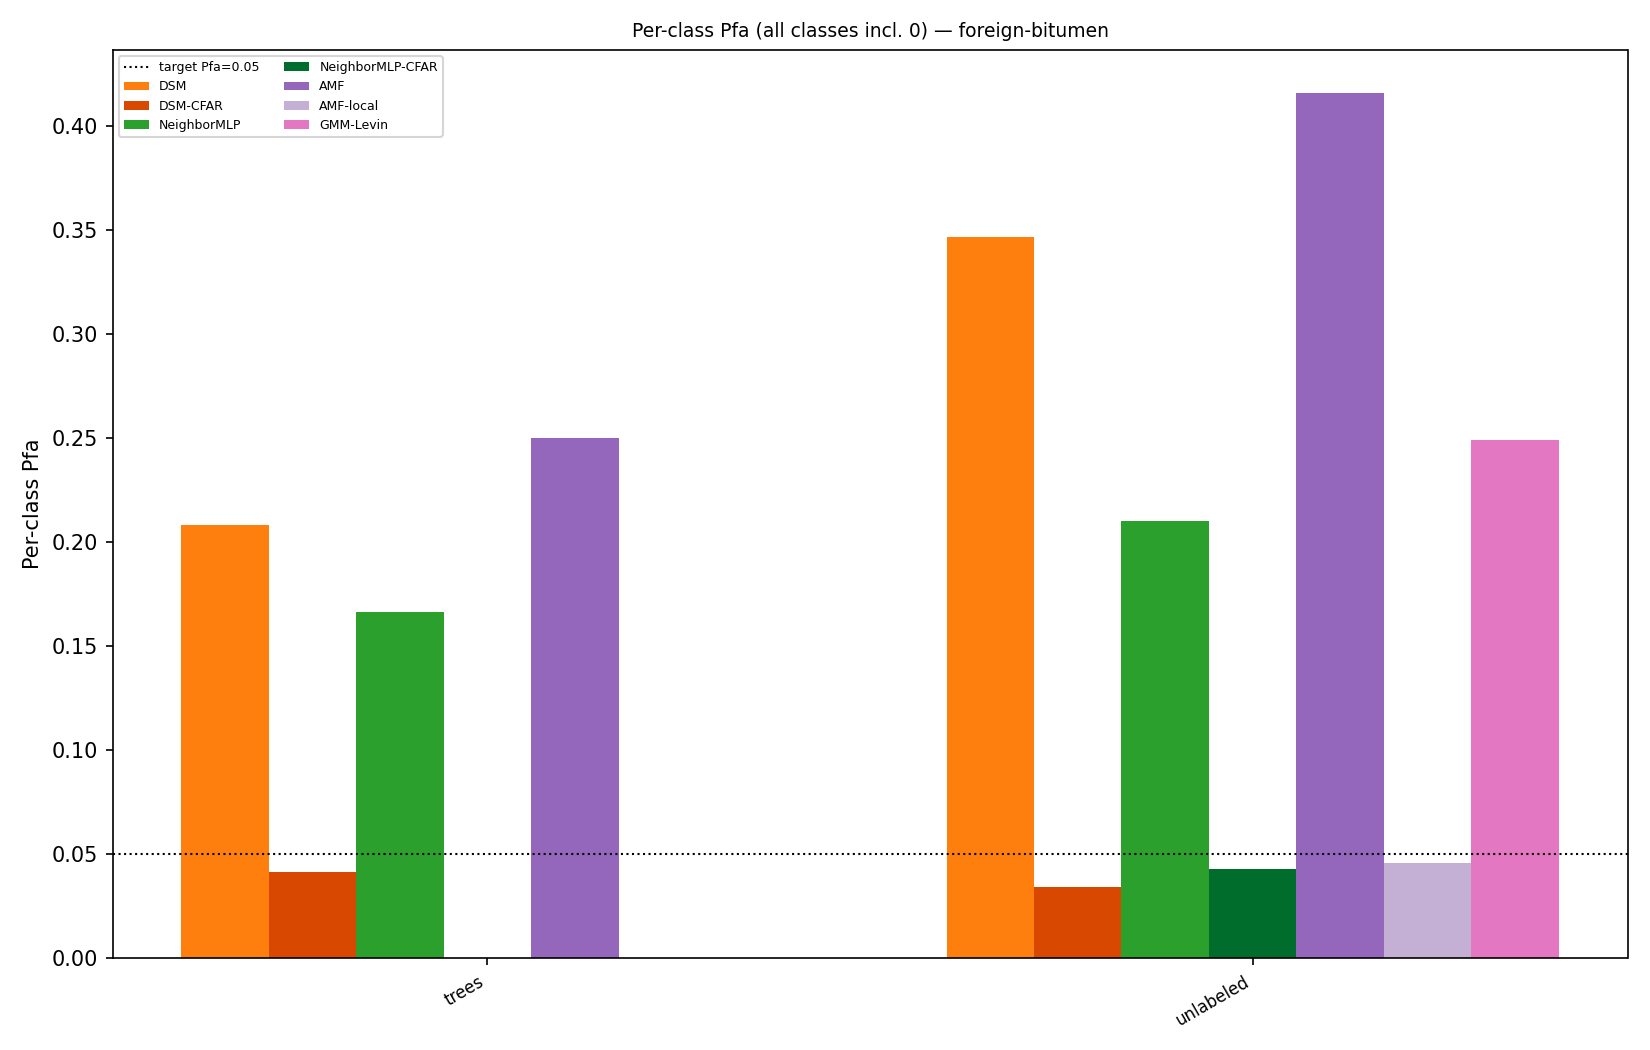

── false_alarms_falsecolor.png ──


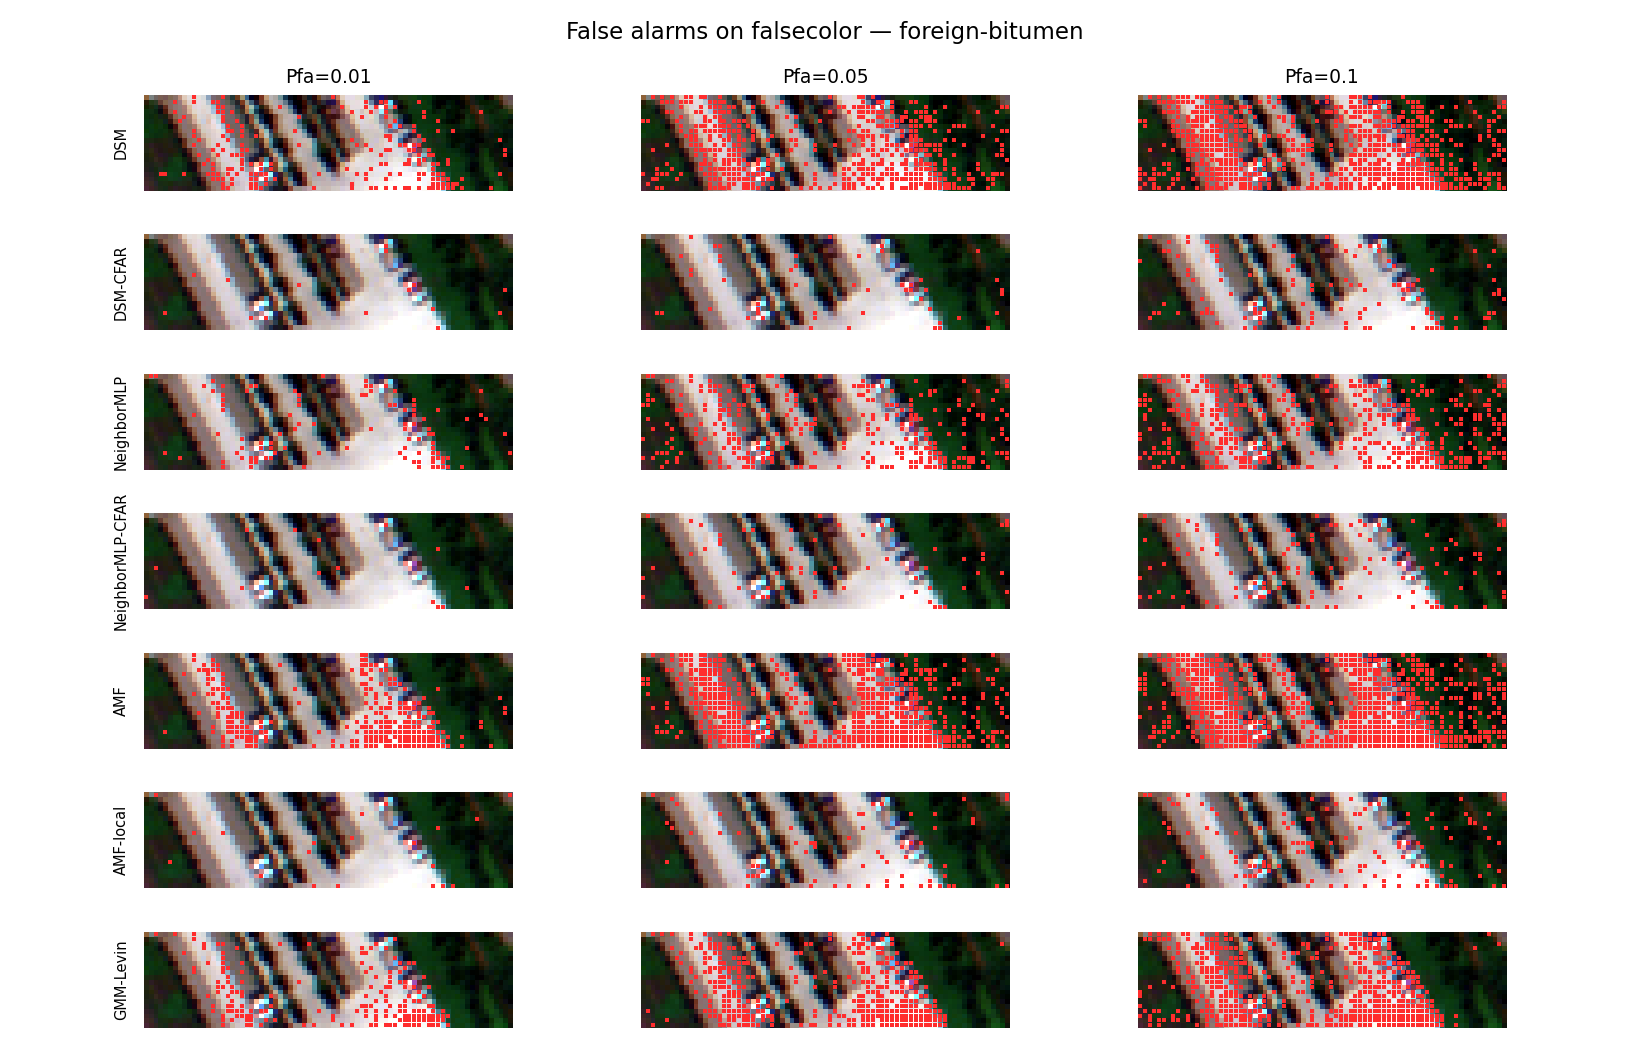

── false_alarms_labelmap.png ──


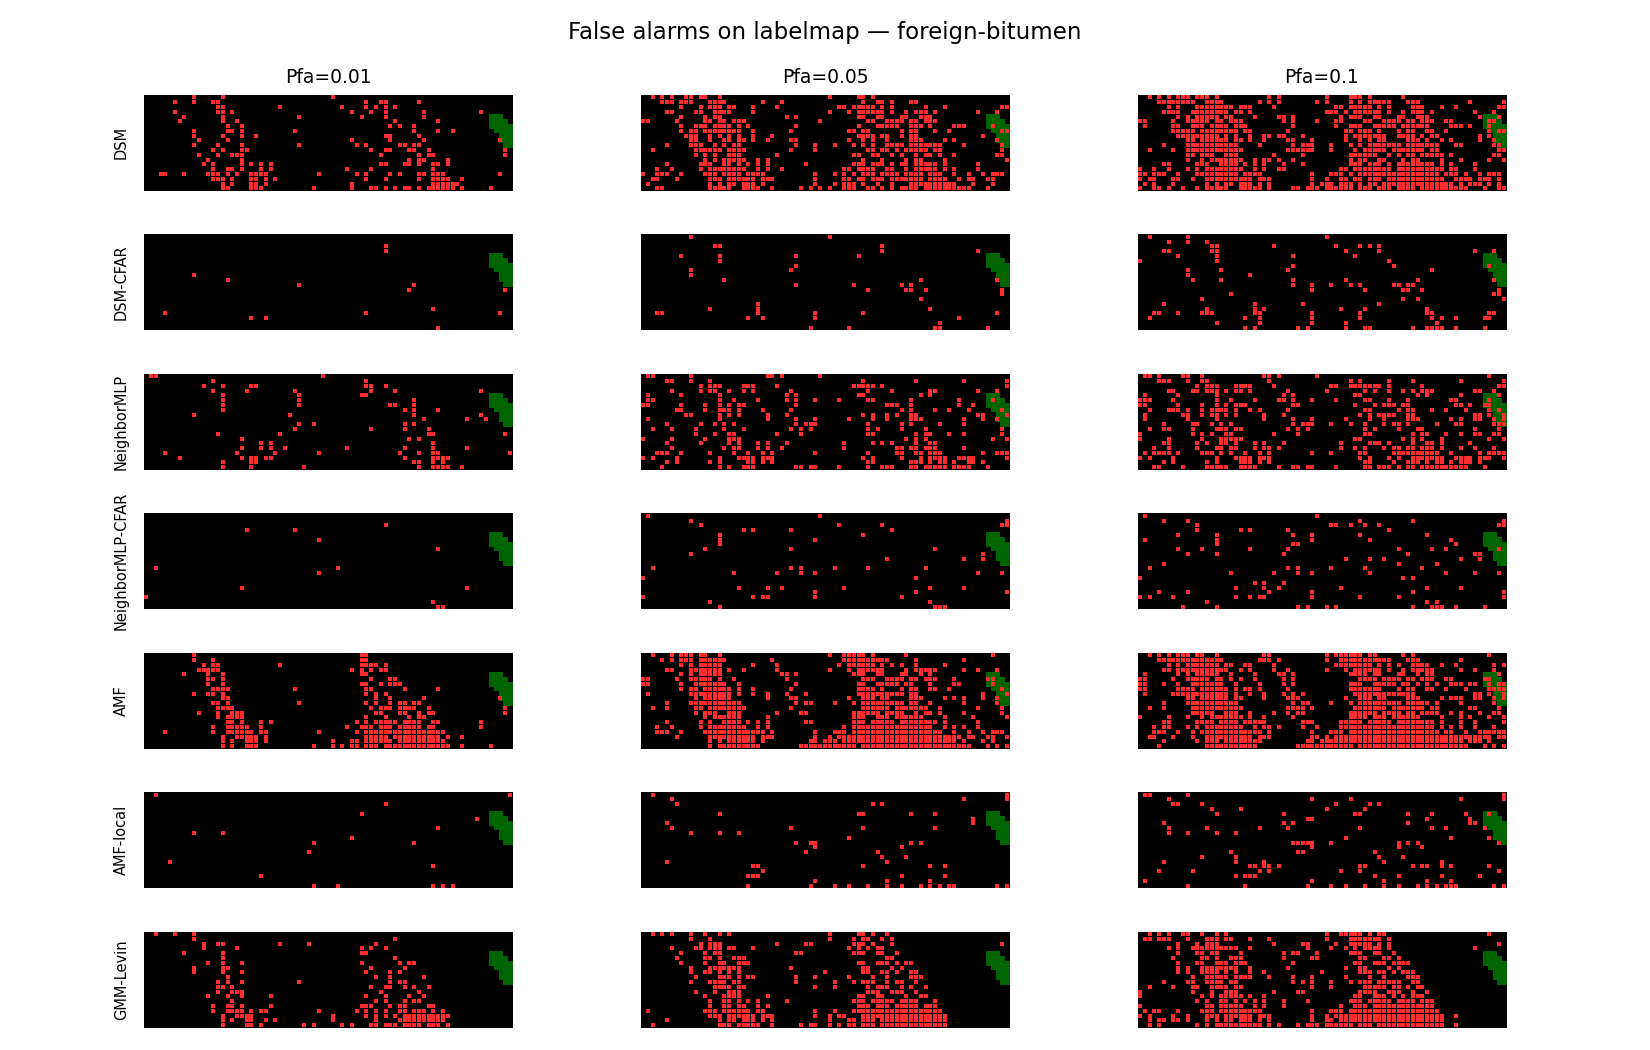


=== Summary Table ===
| Detector | pAUC@0.05 | AUC | Pd@Pfa=0.05 | Pd_cfar | Pfa_avg | Pfa_max | Pfa[unlabeled] | Pfa[trees] |
|---|---|---|---|---|---|---|---|---|
| DSM | 0.148 | 0.800 | 0.333 | 0.798 | 0.277 | 0.347 | 0.347 | 0.208 |
| DSM-CFAR | 0.200 | 0.809 | 0.394 | 0.343 | 0.038 | 0.042 | 0.035 | 0.042 |
| NeighborMLP | 0.218 | 0.828 | 0.475 | 0.798 | 0.188 | 0.210 | 0.210 | 0.167 |
| NeighborMLP-CFAR | 0.286 | 0.831 | 0.444 | 0.394 | 0.022 | 0.043 | 0.043 | 0.000 |
| AMF | 0.093 | 0.735 | 0.192 | 0.768 | 0.333 | 0.416 | 0.416 | 0.250 |
| AMF-local | 0.173 | 0.770 | 0.333 | 0.313 | 0.023 | 0.046 | 0.046 | 0.000 |
| GMM-Levin | 0.104 | 0.764 | 0.152 | 0.697 | 0.125 | 0.249 | 0.249 | 0.000 |



In [8]:
# ── Scenario 2 — manual box 2 ─────────────────────────────────────────
# dominant in scene = trees
# FOREIGN candidates (classes ABSENT from this scene — pick one as foreign_class):
#   1=asphalt, 2=meadows, 3=gravel, 5=metal_sheets, 6=bare_soil, 7=bitumen, 8=bricks, 9=shadows
ov = dict(BASE)
ov['scenario_index'] = 2

# ── pick the foreign (out-of-scene) target ──
ov['foreign_class']  = 7     # ← change to any absent class id above

# ── per-scene tuning (uncomment to override BASE) ──
# ov['amplitude']        = 0.15
# ov['target_fraction']  = 0.10
# ov['k']                = 5
# ov['n_budget']         = None
# ov['nmlp_K']           = 7
# ov['active_detectors'] = ['NeighborMLP', 'NeighborMLP-CFAR', 'AMF', 'GMM-Levin']

# runs all SEEDS, aggregates to a mean±std table + bar figures
ms_dir_2 = run_seeds_and_show(ov, seeds=SEEDS)

## Scenario 4 — random box (seed 42)

In [ ]:
# ── Scenario 4 — random box (seed 42) ─────────────────────────────────────────
# dominant in scene = asphalt
# FOREIGN candidates (classes ABSENT from this scene — pick one as foreign_class):
#   2=meadows, 3=gravel, 5=metal_sheets, 6=bare_soil, 7=bitumen, 8=bricks, 9=shadows
ov = dict(BASE)
ov['scenario_index'] = 4

# ── pick the foreign (out-of-scene) target ──
ov['foreign_class']  = 7     # ← change to any absent class id above

# ── per-scene tuning (uncomment to override BASE) ──
# ov['amplitude']        = 0.15
# ov['target_fraction']  = 0.10
# ov['k']                = 5
# ov['n_budget']         = None
# ov['nmlp_K']           = 7
# ov['active_detectors'] = ['NeighborMLP', 'NeighborMLP-CFAR', 'AMF', 'GMM-Levin']

# runs all SEEDS, aggregates to a mean±std table + bar figures
ms_dir_4 = run_seeds_and_show(ov, seeds=SEEDS)


########## MULTI-SEED  seeds=[42, 43, 44, 45, 46]  -> /content/drive/MyDrive/final_paper/spatial_results/multiseed_20260612_183248

===== seed 42  (1/5) =====
Device: cuda
Loading data ...
Image 610×340×103
Scenario 4: train_box=[85, 193, 207, 306]  test_box=[419, 508, 250, 334]
train=10692 px  (box [85, 193, 207, 306])
test=7476 px  (89×84)
AMF-local window=15×15 (independent of k=5)
in-patch signature: dominant=asphalt  ||s||=1.373e+04
foreign signature: class=bitumen  scaled ||s||=1.436e+04
Training DSM ...


DSM:   0%|          | 0/1000 [00:00<?, ?it/s, loss=2056.5457]

    [DSM] epoch 1/1000  loss=2056.5457  best=2056.5457


DSM:  10%|▉         | 98/1000 [00:07<01:05, 13.81it/s, loss=1750.7798]

    [DSM] epoch 100/1000  loss=1750.7798  best=1747.1533


...

NeighborMLP:  70%|██████▉   | 698/1000 [00:53<00:23, 12.71it/s, loss=1746.1076]

    [NeighborMLP] epoch 700/1000  loss=1746.1076  best=1734.7268


NeighborMLP:  80%|███████▉  | 798/1000 [01:00<00:14, 14.11it/s, loss=1738.1984]

    [NeighborMLP] epoch 800/1000  loss=1738.1984  best=1734.0016


NeighborMLP:  86%|████████▌ | 858/1000 [01:05<00:12, 11.30it/s, loss=1740.1602]

## Combined summary — all scenarios (mean ± std over seeds)

In [ ]:
# Change scoring knobs (foreign_class, amplitude, pfa_target, active_detectors,
# gmm_K, edge_guard, amf_local_window, dsm_cfar_window ...) on an EXISTING trained
# model WITHOUT retraining. Each multiseed dir holds one trained model per seed
# under seeds/compare_*/models.pt.
import subprocess, sys, tempfile, yaml, os, glob

# pick the first seed's trained model from scenario 0's multiseed run
MODELS = sorted(glob.glob(os.path.join(ms_dir_0, 'seeds', 'compare_*', 'models.pt')))[0]
print('re-extracting from', MODELS)

SCORING = dict(
    results_dir   = RESULTS,
    dataset       = DATASET,
    manual_boxes_path = MANUAL,
    run_inpatch   = False, run_foreign = True,
    foreign_class = 3,          # ← re-target to gravel, etc.
    amplitude     = 0.15,
    pfa_target    = 0.05,
    amf_local_window = 7,       # AMF-local window (re-scored, no retrain)
    dsm_cfar_window  = 11,      # DSM-CFAR window
    dsm_cfar_guard   = 3,
    active_detectors = ['DSM','DSM-CFAR','NeighborMLP','NeighborMLP-CFAR',
                        'AMF','AMF-local','GMM-Levin'],
)
tmp = tempfile.NamedTemporaryFile('w', suffix='.yaml', delete=False)
yaml.dump(SCORING, tmp); tmp.close()
subprocess.run([sys.executable, '-u',
                '/content/proj/experiments/spatial/run_compare.py',
                '--from-models', MODELS, '--config', tmp.name])
os.unlink(tmp.name)
new = sorted(glob.glob(f'{RESULTS}/compare_*'))[-1]
import importlib, run_compare as rc; importlib.reload(rc)
rc.show_plots_from_dir(new, sub='foreign')

## Re-extract / re-target a saved run (no retraining)

In [ ]:
# Change scoring knobs (foreign_class, amplitude, pfa_target, active_detectors,
# gmm_K, edge_guard, amf_local_window, dsm_cfar_window ...) on an EXISTING run
# without retraining the nets.
import subprocess, sys, tempfile, yaml, os, glob

RUN_DIR = run_dir_0   # ← any compare_* folder that has models.pt

SCORING = dict(
    results_dir   = RESULTS,
    dataset       = DATASET,
    manual_boxes_path = MANUAL,
    run_inpatch   = False, run_foreign = True,
    foreign_class = 3,          # ← re-target to gravel, etc.
    amplitude     = 0.15,
    pfa_target    = 0.05,
    amf_local_window = 7,       # AMF-local window (re-scored, no retrain)
    dsm_cfar_window  = 11,      # DSM-CFAR window
    dsm_cfar_guard   = 3,
    active_detectors = ['DSM','DSM-CFAR','NeighborMLP','NeighborMLP-CFAR',
                        'AMF','AMF-local','GMM-Levin'],
)
tmp = tempfile.NamedTemporaryFile('w', suffix='.yaml', delete=False)
yaml.dump(SCORING, tmp); tmp.close()
subprocess.run([sys.executable, '-u',
                '/content/proj/experiments/spatial/run_compare.py',
                '--from-models', f'{RUN_DIR}/models.pt', '--config', tmp.name])
os.unlink(tmp.name)
new = sorted(glob.glob(f'{RESULTS}/compare_*'))[-1]
import importlib, run_compare as rc; importlib.reload(rc)
rc.show_plots_from_dir(new, sub='foreign')